# Section 5.2: Test 1 - Ontological Innovation in Sensory Modalities

This notebook analyzes AI-generated proposals for ninth sensory modalities and determines whether they represent genuine ontological innovation or recombination of existing eight modalities.

In [52]:
import json, warnings
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from scipy.spatial import ConvexHull, Delaunay
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Project-wide style
from setups.viz_styles import apply_project_style
apply_project_style()

Path("results/test1").mkdir(parents=True, exist_ok=True)
path_test1_results = "results/test1_cleaned.csv"
path_test1_ai_proposals = "results/test1_ontological_innovation/ai_proposals.json"
path_modality_descriptions = "data/modality_descriptions.json"

In [53]:
# Shared visualization palettes / typography / thresholds.
import importlib
import setups.viz_styles as _viz_styles

importlib.reload(_viz_styles)

from setups.viz_styles import (
    fw,
    WHITE_SKY_CMAP,
    SKY_WHITE_GRAY_CMAP,
    BLUE_GRAY_RAMP,
    THRESHOLD_COLOR,
    MODEL_VISIBLE_COLORS,
    TITLE_SIZE,
    LABEL_SIZE,
    TICK_SIZE,
    LEGEND_SIZE,
    CBAR_TICK_SIZE,
    CBAR_LABEL_SIZE,
    MARKER_SIZE_L,
    MARKER_SIZE_M,
    MARKER_SIZE_S,
    MARKER_EDGE_WIDTH,
    MARKER_EDGE_WIDTH_STANDARD,
)

from setups.thresholds import (
    T1_NOVELTY_FRONTIER_SIM_THRESHOLD as NOVELTY_FRONTIER_SIM_THRESHOLD,
    EMBED_MODEL_NAME,
)

## 1. Load AI-Generated Modality Proposals

### Modality Config Contract

This notebook expects `data/modality_descriptions.json` to use the shared schema:

- `modalities_order`: ordered list of modality ids.
- `modality_descriptions`: mapping `{modality -> description text}`.
- `extension_keywords`: mapping `{modality -> [keywords...]}`.

All modality-dependent analysis should read from these loaded structures instead of hardcoded modality lists or keyword maps.

In [25]:
# Load modality descriptions and keywords from shared JSON
modality_descriptions_file = Path(path_modality_descriptions)
if not modality_descriptions_file.exists():
    raise FileNotFoundError(f"Missing file: {modality_descriptions_file}")

with open(modality_descriptions_file, "r", encoding="utf-8") as f:
    modality_config = json.load(f)

required_config_keys = ["modalities_order", "modality_descriptions", "extension_keywords"]
missing_config_keys = [k for k in required_config_keys if k not in modality_config]
if missing_config_keys:
    raise KeyError(
        f"Missing required keys in {modality_descriptions_file}: {missing_config_keys}"
    )

modalities = [str(m).strip().lower() for m in modality_config["modalities_order"]]
modality_descriptions = modality_config["modality_descriptions"]
extension_keywords = modality_config["extension_keywords"]

missing_modalities = [m for m in modalities if not str(modality_descriptions.get(m, "")).strip()]
if missing_modalities:
    raise KeyError(
        f"Missing modality descriptions in {modality_descriptions_file}: {missing_modalities}"
    )

missing_extension_keywords = [m for m in modalities if m not in extension_keywords]
if missing_extension_keywords:
    raise KeyError(
        f"Missing extension keywords in {modality_descriptions_file}: {missing_extension_keywords}"
    )

modalities_df = pd.DataFrame(
    {
        "modality": modalities,
        "description": [modality_descriptions[m] for m in modalities],
        "extension_keywords": [", ".join(extension_keywords[m]) for m in modalities],
    }
)

print(f"Loaded modality configuration for {len(modalities)} modalities.")
display(modalities_df)

Loaded modality configuration for 8 modalities.


,modality,description,extension_keywords
0,visual,Visual sensation detects electromagnetic radia...,"electromagnetic, radiation, spectrum, waveleng..."
1,auditory,Auditory sensation detects mechanical sound wa...,"sound, acoustic, frequency, infrasound, ultras..."
2,tactile,Tactile sensation detects mechanical vibration...,"pressure, mechanical, touch, vibration, surface"
3,olfactory,Olfactory sensation detects airborne chemical ...,"chemical, molecule, scent, smell, airborne"
4,gustatory,Gustatory sensation detects dissolved chemical...,"taste, chemical, molecule, dissolved"
5,proprioceptive,Proprioceptive sensation detects body position...,"joint, muscle, tendon, body position, kinesthetic"
6,vestibular,"Vestibular sensation detects head position, li...","vestibular, equilibrium, balance, acceleration..."
7,interoceptive,Interoceptive sensation detects internal physi...,"heartbeat, respiration, hunger, thirst, fatigu..."


In [26]:
# Load processed Test 1 results exported by 2-test1-ontological-innovation.ipynb
test1_results = pd.read_csv(path_test1_results)

print(test1_results.columns.tolist())

# Support both legacy and current schemas
preview_candidates = [
    "model",
    "proposal_id",
    "proposal_name",      # current
    "modality_name",      # legacy
    "is_novel",           # current novelty label
    "ontologically_novel",# legacy novelty label
    "novelty_score",      # legacy novelty score
    "max_similarity",
]
preview_cols = [c for c in preview_candidates if c in test1_results.columns]

print(f"Preview columns used: {preview_cols}")
test1_results[preview_cols].head()

['proposal_id', 'proposal_name', 'model', 'is_extension', 'is_hybrid', 'is_functional_recomb', 'is_traceable', 'related_modalities', 'inside_convex_hull', 'closest_modality', 'max_similarity', 'avg_similarity', 'lit_matches', 'lit_best_score', 'lit_best_text', 'lit_best_title', 'lit_best_source_type', 'lit_best_evidence_tier', 'novelty_semantic_proxy', 'novelty_frontier_distance_proxy', 'continuous_novelty_score', 'is_novel']
Preview columns used: ['model', 'proposal_id', 'proposal_name', 'is_novel', 'max_similarity']


,model,proposal_id,proposal_name,is_novel,max_similarity
0,deepseek-v3.2,sample_000,Chronesthesia,NO,0.448774
1,mistral-large,sample_001,Temporal Resonance Perception (TRP),NO,0.297537
2,deepseek-v3.2,sample_002,Chronoperception,NO,0.348915
3,llama-3.3-70b-instruct,sample_003,Chronoceptive Modality,NO,0.395404
4,deepseek-v3.2,sample_004,Temporoceptive,NO,0.306830


In [27]:
test1_results.loc[:, ['is_extension', 'is_hybrid', 'is_functional_recomb', 'is_traceable','inside_convex_hull']]

,is_extension,is_hybrid,is_functional_recomb,is_traceable,inside_convex_hull
0,False,False,False,True,True
1,True,False,False,True,True
2,False,False,False,True,True
3,False,False,False,True,True
4,False,False,True,True,True
...,...,...,...,...,...
163,False,False,False,True,True
164,True,True,False,True,True
165,False,False,False,True,True
166,False,False,False,True,True


## 2. Structural Analysis: Decomposition into Existing Modalities

In [28]:
# Harmonize schema for downstream cells while using results/test1_cleaned.csv as source of truth.
test1_results = pd.read_csv(path_test1_results)

In [29]:
def _is_blank(series: pd.Series) -> pd.Series:
    return series.isna() | series.astype(str).str.strip().eq("")

# Harmonize to analysis schema based on results/test1_cleaned.csv columns.
# proposal_name = AI-generated theory label
test1_results["proposal_name"] = test1_results["proposal_name"].astype(str).str.strip()

name_blank = _is_blank(test1_results["closest_modality"])
test1_results.loc[name_blank, "closest_modality"] = test1_results.loc[name_blank, "proposal_name"]

# Use canonical proposal descriptions exported by 2-test1-ontological-innovation.ipynb.
proposals_json_file = Path(path_test1_ai_proposals)
if not proposals_json_file.exists():
    raise FileNotFoundError(
        f"Missing canonical proposals file: {proposals_json_file}. "
        "Run 2-test1-ontological-innovation.ipynb through proposal construction first."
    )

with proposals_json_file.open("r", encoding="utf-8") as f:
    proposals_records = json.load(f)

proposals_df = pd.DataFrame(proposals_records)
required_proposal_cols = ["proposal_id", "description"]
missing_proposal_cols = [c for c in required_proposal_cols if c not in proposals_df.columns]
if missing_proposal_cols:
    raise KeyError(
        f"Missing required columns in {proposals_json_file}: {missing_proposal_cols}"
    )

# Merge canonical descriptions by proposal_id; this ensures both notebooks embed the same text.
proposal_desc_map = proposals_df.set_index("proposal_id")["description"].astype(str)
test1_results["description"] = test1_results["proposal_id"].map(proposal_desc_map)

desc_blank = _is_blank(test1_results["description"])
test1_results.loc[desc_blank, "description"] = test1_results.loc[desc_blank, "proposal_name"]

# Derive novelty score from similarity because cleaned CSV has no explicit novelty_score.
sim = pd.to_numeric(test1_results["max_similarity"], errors="coerce")
test1_results["novelty_score"] = (1.0 - sim).clip(lower=0.0, upper=1.0)

test1_results["is_range_extension"] = test1_results["is_extension"].fillna(False).astype(bool)
test1_results["is_hybrid"] = test1_results["is_hybrid"].fillna(False).astype(bool)

# Prefer source `is_traceable`; derive it from lit_matches for legacy exports.
if "is_traceable" in test1_results.columns:
    test1_results["is_traceable"] = test1_results["is_traceable"].fillna(False).astype(bool)
else:
    test1_results["is_traceable"] = pd.to_numeric(
        test1_results.get("lit_matches", 0), errors="coerce"
    ).fillna(0).gt(0)

print(f"Loaded {len(test1_results)} proposals from {path_test1_results}")
print(f"Merged canonical descriptions from: {proposals_json_file}")
preview_cols = [
    "model", "proposal_id", "proposal_name",
    "description", "novelty_score", "max_similarity", "is_traceable",
    "closest_modality",
 ]
display(test1_results[preview_cols].head())

Loaded 168 proposals from results/test1_cleaned.csv
Merged canonical descriptions from: results/test1_ontological_innovation/ai_proposals.json


,model,proposal_id,proposal_name,description,novelty_score,max_similarity,is_traceable,closest_modality
0,deepseek-v3.2,sample_000,Chronesthesia,"Detection of fundamental, quantum-level fluctu...",0.551226,0.448774,True,PROPRIOCEPTIVE
1,mistral-large,sample_001,Temporal Resonance Perception (TRP),"Detection of minute, localized distortions in ...",0.702463,0.297537,True,VISUAL
2,deepseek-v3.2,sample_002,Chronoperception,Direct detection of temporal gradients and pha...,0.651085,0.348915,True,PROPRIOCEPTIVE
3,llama-3.3-70b-instruct,sample_003,Chronoceptive Modality,The chronoceptive modality detects the tempora...,0.604596,0.395404,True,INTEROCEPTIVE
4,deepseek-v3.2,sample_004,Temporoceptive,Direct detection of the local rate of time flo...,0.693170,0.306830,True,VESTIBULAR


## 3. Literature Traceability Analysis

In [8]:
if "is_traceable" in test1_results.columns:
    traceable = test1_results["is_traceable"].fillna(False).astype(bool)
else:
    traceable = pd.to_numeric(test1_results.get("lit_matches", 0), errors="coerce").fillna(0).gt(0)
mean_sim = pd.to_numeric(test1_results["max_similarity"], errors="coerce").mean()

print("\nLiterature Traceability (from cleaned data):")
print(f"Traceable to literature: {int(traceable.sum())} ({traceable.mean():.1%})")
print(f"Mean similarity to known concepts: {mean_sim:.3f}")


Literature Traceability (from cleaned data):
Traceable to literature: 164 (97.6%)
Mean similarity to known concepts: 0.305


## 4. Embedding Space Analysis

In [9]:
def select_embedding_texts(df: pd.DataFrame) -> tuple[list[str], str]:
    """Pick the best available text field with non-empty and diverse content."""
    candidates = ["description", "proposal_name", "closest_modality", "lit_best_text"]
    best_col = None
    best_score = -1.0
    best_series = None

    for col in candidates:
        if col not in df.columns:
            continue
        s = df[col].fillna("").astype(str).str.strip()
        nonempty = s[s != ""]
        if nonempty.empty:
            continue
        coverage = len(nonempty) / len(df) if len(df) else 0.0
        diversity = nonempty.nunique() / len(nonempty)
        score = 0.7 * coverage + 0.3 * diversity
        if score > best_score:
            best_score = score
            best_col = col
            best_series = s

    if best_series is None:
        return ([""] * len(df), "<empty>")

    # Fill remaining blanks with fallback name fields to avoid empty embeddings.
    fallback_cols = [c for c in ["proposal_name", "closest_modality", "lit_best_text"] if c in df.columns and c != best_col]
    out = best_series.copy()
    for c in fallback_cols:
        fb = df[c].fillna("").astype(str).str.strip()
        out = out.where(out != "", fb)

    return (out.fillna("").astype(str).tolist(), best_col)

proposal_texts, selected_text_col = select_embedding_texts(test1_results)

missing_modalities = [m for m in modalities if m not in modality_descriptions]
if missing_modalities:
    raise KeyError(
        f"Missing modality descriptions in {modality_descriptions_file}: {missing_modalities}"
    )

existing_descriptions = [modality_descriptions[m] for m in modalities]

n_dims = 384
existing_embeddings = np.random.randn(len(existing_descriptions), n_dims)

# One embedding per proposal (placeholder around mean of existing)
proposal_embeddings = (
    existing_embeddings.mean(axis=0)
    + np.random.randn(len(test1_results), n_dims) * 0.3
)

def test_convex_hull_membership(existing_points: np.ndarray,
                                new_points: np.ndarray):
    """Test if new points lie within convex hull of existing points."""
    pca = PCA(n_components=2)
    existing_2d = pca.fit_transform(existing_points)
    new_2d = pca.transform(new_points)

    hull = ConvexHull(existing_2d)
    delaunay = Delaunay(existing_2d)
    inside = delaunay.find_simplex(new_2d) >= 0
    return inside, existing_2d, new_2d, hull

inside_hull, existing_2d, new_2d, hull = test_convex_hull_membership(
    existing_embeddings, proposal_embeddings
)

# Attach to the cleaned proposals DataFrame
test1_results["inside_convex_hull"] = inside_hull

print("\nEmbedding Space Analysis:")
print(f"Text source used for embeddings: {selected_text_col}")
print(
    f"Proposals inside training convex hull: {inside_hull.sum()} "
    f"({inside_hull.mean():.1%})"
)
print(
    f"Proposals outside convex hull: {(~inside_hull).sum()} "
    f"({(~inside_hull).mean():.1%})"
)


Embedding Space Analysis:
Text source used for embeddings: description
Proposals inside training convex hull: 168 (100.0%)
Proposals outside convex hull: 0 (0.0%)


In [10]:
# 2) Prepare texts from shared modality config loaded at notebook start
missing_modalities = [m for m in modalities if m not in modality_descriptions]
if missing_modalities:
    raise KeyError(
        f"Missing modality descriptions in {modality_descriptions_file}: {missing_modalities}"
    )

training_descriptions = [modality_descriptions[m] for m in modalities]

# Canonical source alignment: use proposal descriptions merged from ai_proposals.json.
if "description" in test1_results.columns:
    desc_series = test1_results["description"].fillna("").astype(str).str.strip()
    if (desc_series != "").all():
        proposal_texts = desc_series.tolist()
        selected_text_col = "description"
    else:
        # Fallback only for missing description rows.
        fallback_col = "proposal_name" if "proposal_name" in test1_results.columns else "lit_best_text"
        fallback_series = test1_results.get(fallback_col, pd.Series([""] * len(test1_results))).fillna("").astype(str).str.strip()
        proposal_texts = desc_series.where(desc_series != "", fallback_series).tolist()
        selected_text_col = f"description (+ {fallback_col} fallback)"
else:
    fallback_col = "proposal_name" if "proposal_name" in test1_results.columns else "lit_best_text"
    proposal_texts = test1_results.get(fallback_col, pd.Series([""] * len(test1_results))).fillna("").astype(str).tolist()
    selected_text_col = fallback_col

# 3) Embed with the same model
embedder = SentenceTransformer(EMBED_MODEL_NAME)
training_embeddings = embedder.encode(training_descriptions)
proposal_embeddings = embedder.encode(proposal_texts)

# 4) PCA + convex hull (aligned with 2-test1-ontological-innovation.ipynb)
target_dim = min(3, training_embeddings.shape[0] - 1)
pca = PCA(n_components=target_dim)
training_emb_reduced = pca.fit_transform(training_embeddings)
proposal_emb_reduced = pca.transform(proposal_embeddings)

training_hull = ConvexHull(training_emb_reduced)

def point_in_convex_hull_3d(point_reduced, hull, tol=1e-4):
    A = hull.equations[:, :-1]
    b = hull.equations[:, -1]
    vals = A @ point_reduced + b
    # Numerical guard: near-zero positive residuals are boundary points, not true outside points.
    return bool(np.all(vals <= tol)), float(np.maximum(vals, 0.0).max())

inside_hull_3d = []
outside_violation = []
for i in range(len(test1_results)):
    inside, violation = point_in_convex_hull_3d(proposal_emb_reduced[i], training_hull)
    inside_hull_3d.append(inside)
    outside_violation.append(violation)

inside_hull_3d = np.array(inside_hull_3d)
outside_violation = np.array(outside_violation)

# 5) 2D projection for plotting + optional 2D diagnostic membership
training_2d = training_emb_reduced[:, :2]
proposal_2d = proposal_emb_reduced[:, :2]
inside_hull_2d = Delaunay(training_2d).find_simplex(proposal_2d) >= 0

# Canonical result must match the main test1 notebook: hull status from 3D PCA space.
inside_hull = inside_hull_3d
test1_results["inside_convex_hull"] = inside_hull_3d
test1_results["inside_convex_hull_2d_plot"] = inside_hull_2d

print(f"Embedding text source: {selected_text_col}")
print(f"Inside hull (3D PCA canonical): {inside_hull_3d.sum()} / {len(inside_hull_3d)}")
print(f"Outside hull (3D PCA canonical): {(~inside_hull_3d).sum()} / {len(inside_hull_3d)}")
print(f"Inside hull (2D projected diagnostic): {inside_hull_2d.sum()} / {len(inside_hull_2d)}")
print(f"3D vs 2D mismatch count: {(inside_hull_3d != inside_hull_2d).sum()}")
print(f"Max 3D hull violation (diagnostics): {outside_violation.max():.2e}")

Embedding text source: description
Inside hull (3D PCA canonical): 168 / 168
Outside hull (3D PCA canonical): 0 / 168
Inside hull (2D projected diagnostic): 168 / 168
3D vs 2D mismatch count: 0
Max 3D hull violation (diagnostics): 0.00e+00


## 5. Visualization: Embedding Space with Convex Hull

In [72]:
def _modality_label(text: str) -> str:
    return str(text).replace("_", " ").strip().capitalize()


def plot_embedding_space(
    training_emb_reduced: np.ndarray,
    proposal_emb_reduced: np.ndarray,
    modalities: list[str],
    inside_hull: np.ndarray,
    save_path: str,
    membership_label: str = "3D PCA",
    annotate_proposals: bool = False,
) -> None:
    """2D PCA projection: training modalities and proposal points."""
    training_2d = training_emb_reduced[:, :2]
    proposal_2d = proposal_emb_reduced[:, :2]

    fig, ax = plt.subplots(figsize=fw(4.11))
    train_scatter = ax.scatter(
        training_2d[:, 0],
        training_2d[:, 1],
        s=MARKER_SIZE_M,
        c=BLUE_GRAY_RAMP[2],
        marker="o",
        alpha=0.75,
        edgecolors="black",
        linewidths=MARKER_EDGE_WIDTH,
        label="Training modalities",
    )

    # Shared label placement rule for all modalities.
    for index, modality in enumerate(modalities):
        label = _modality_label(modality)
        ax.annotate(
            label,
            (training_2d[index, 0], training_2d[index, 1]),
            xytext=(8, 0),
            textcoords="offset points",
            fontsize=TICK_SIZE,
            fontweight="bold",
            ha="left",
            va="center",
            clip_on=True,
        )

    if len(training_2d) >= 3:
        for simplex in ConvexHull(training_2d).simplices:
            ax.plot(
                training_2d[simplex, 0],
                training_2d[simplex, 1],
                "k-",
                alpha=0.3,
                linewidth=1,
            )

    colors = np.where(inside_hull.astype(bool), BLUE_GRAY_RAMP[4], BLUE_GRAY_RAMP[0])
    markers = np.where(inside_hull.astype(bool), "o", "^")

    for index in range(len(proposal_2d)):
        ax.scatter(
            proposal_2d[index, 0],
            proposal_2d[index, 1],
            s=MARKER_SIZE_S,
            c=colors[index],
            marker=markers[index],
            alpha=0.8,
            edgecolors="black",
            linewidths=MARKER_EDGE_WIDTH_STANDARD,
        )
        if annotate_proposals:
            ax.annotate(
                f"P{index + 1}",
                (proposal_2d[index, 0], proposal_2d[index, 1]),
                xytext=(5, 0),
                textcoords="offset points",
                fontsize=TICK_SIZE,
                fontweight="bold",
                clip_on=True,
            )

    inside_handle = ax.scatter(
        [],
        [],
        s=MARKER_SIZE_S,
        c=BLUE_GRAY_RAMP[4],
        marker="o",
        edgecolors="black",
        linewidths=MARKER_EDGE_WIDTH_STANDARD,
        label="Proposals inside hull",
    )
    outside_handle = ax.scatter(
        [],
        [],
        s=MARKER_SIZE_S,
        c=BLUE_GRAY_RAMP[0],
        marker="^",
        edgecolors="black",
        linewidths=MARKER_EDGE_WIDTH_STANDARD,
        label=f"Proposals outside hull",
    )

    ax.legend(handles=[train_scatter, inside_handle, outside_handle], loc="upper right", fontsize=LEGEND_SIZE)
    ax.set_xlabel("PCA dim 1", fontsize=LABEL_SIZE)
    ax.set_ylabel("PCA dim 2", fontsize=LABEL_SIZE)
    ax.set_title(
        "Embedding Space Projection: Training Modalities vs AI Proposals",
        fontsize=TITLE_SIZE,
        fontweight="bold",
    )
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.18, y=0.1)

    plt.tight_layout()
    plt.savefig(save_path, dpi=320, bbox_inches="tight")
    print(f"Visualization saved to: {save_path}")
    plt.show()


Visualization saved to: results/test1/embedding_space_analysis.png


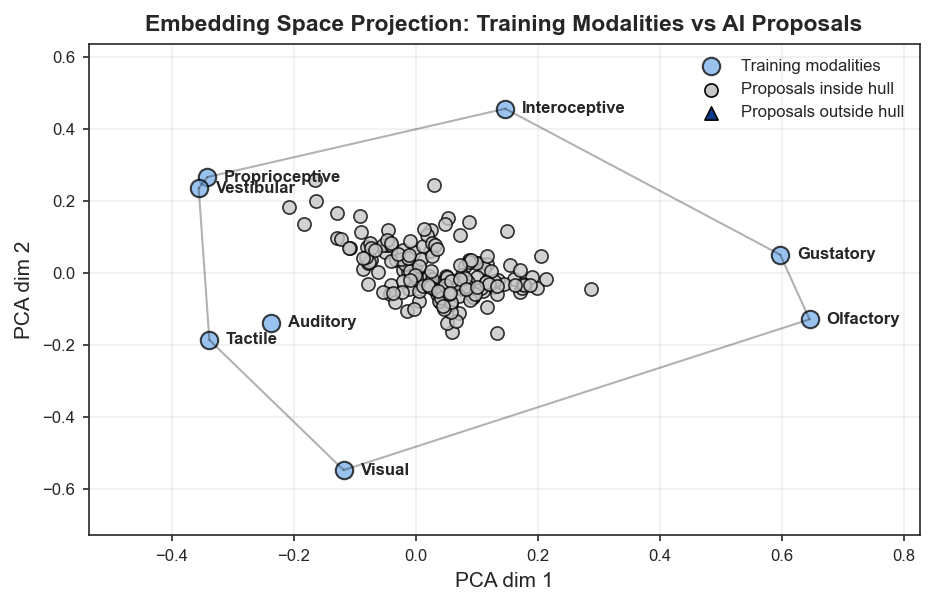

In [73]:
# 2D embedding space — hull membership based on 3D PCA
plot_embedding_space(
    training_emb_reduced=training_emb_reduced,
    proposal_emb_reduced=proposal_emb_reduced,
    modalities=modalities,
    inside_hull=inside_hull_3d,
    membership_label="3D PCA",
    save_path="results/test1/embedding_space_analysis.png",
)

In [69]:
def plot_embedding_space_3d(
    training_emb_reduced: np.ndarray,
    proposal_emb_reduced: np.ndarray,
    modalities: list[str],
    inside_hull_3d: np.ndarray,
    save_path: str,
) -> None:
    """True 3D PCA view with canonical 3D hull membership labels."""
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure(figsize=fw(4))
    ax = fig.add_subplot(111, projection="3d")

    training_z = training_emb_reduced[:, 2] if training_emb_reduced.shape[1] > 2 else np.zeros(len(training_emb_reduced))
    proposal_z = proposal_emb_reduced[:, 2] if proposal_emb_reduced.shape[1] > 2 else np.zeros(len(proposal_emb_reduced))

    ax.scatter(
        training_emb_reduced[:, 0],
        training_emb_reduced[:, 1],
        training_z,
        s=MARKER_SIZE_M,
        c=BLUE_GRAY_RAMP[2],
        marker="o",
        edgecolors="black",
        alpha=0.7,
        linewidths=MARKER_EDGE_WIDTH_STANDARD,
        label="Training modalities",
    )

    for index, modality in enumerate(modalities):
        ax.text(
            training_emb_reduced[index, 0],
            training_emb_reduced[index, 1],
            training_z[index],
            _modality_label(modality),
            fontsize=TICK_SIZE,
            weight="bold",
        )

    inside_mask = inside_hull_3d.astype(bool)
    ax.scatter(
        proposal_emb_reduced[inside_mask, 0],
        proposal_emb_reduced[inside_mask, 1],
        proposal_z[inside_mask],
        s=MARKER_SIZE_S,
        c=BLUE_GRAY_RAMP[4],
        marker="s",
        edgecolors="black",
        alpha=0.8,
        linewidths=MARKER_EDGE_WIDTH_STANDARD,
        label="Proposals inside hull (3D PCA)",
    )

    if (~inside_mask).any():
        outside_mask = ~inside_mask
        ax.scatter(
            proposal_emb_reduced[outside_mask, 0],
            proposal_emb_reduced[outside_mask, 1],
            proposal_z[outside_mask],
            s=MARKER_SIZE_S,
            c=BLUE_GRAY_RAMP[0],
            marker="^",
            edgecolors="black",
            alpha=0.9,
            linewidths=MARKER_EDGE_WIDTH_STANDARD,
            label="Proposals outside hull (3D PCA)",
        )

    ax.set_xlabel("PCA dim 1", fontsize=LABEL_SIZE)
    ax.set_ylabel("PCA dim 2", fontsize=LABEL_SIZE)
    ax.set_zlabel("PCA dim 3", fontsize=LABEL_SIZE)
    ax.set_title("3D PCA Embedding: Training Modalities vs AI Proposals", fontsize=TITLE_SIZE, fontweight="bold")
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.zaxis.set_tick_params(labelsize=TICK_SIZE)
    ax.legend(loc="best", fontsize=LEGEND_SIZE)

    plt.tight_layout()
    plt.savefig(save_path, dpi=320, bbox_inches="tight")
    print(f"Visualization saved to: {save_path}")
    plt.show()

Visualization saved to: results/test1/embedding_space_analysis_3d.png


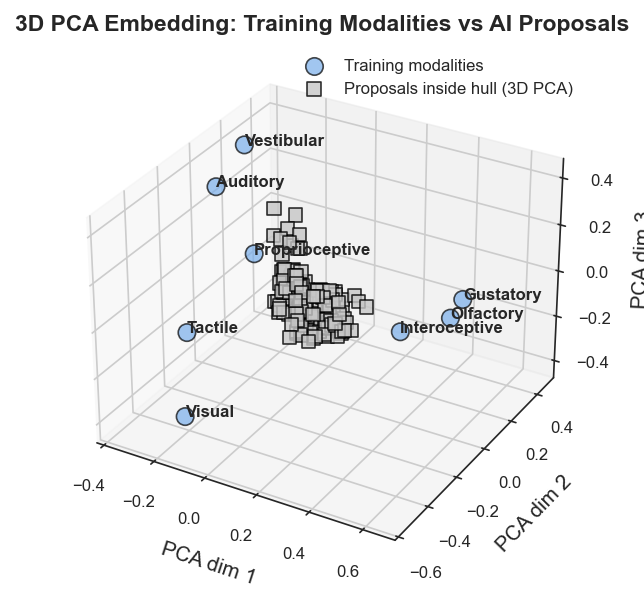

In [51]:
# 3D embedding space
plot_embedding_space_3d(
    training_emb_reduced=training_emb_reduced,
    proposal_emb_reduced=proposal_emb_reduced,
    modalities=modalities,
    inside_hull_3d=inside_hull_3d,
    save_path="results/test1/embedding_space_analysis_3d.png",
)

## 6. Comprehensive Classification of Proposals

### 6.1 Classification Rules and Summary Figures

Apply rule-based classification to Test 1 proposals and visualize class composition and novelty distributions.

In [13]:
test1_results = pd.read_csv(path_test1_results)

def _derive_novelty_proxy(df: pd.DataFrame) -> pd.Series:
    # Prefer explicit novelty score if available; otherwise use inverse similarity proxy.
    if "novelty_score" in df.columns:
        return pd.to_numeric(df["novelty_score"], errors="coerce")
    sim = pd.to_numeric(df.get("max_similarity", np.nan), errors="coerce")
    return (1.0 - sim).clip(lower=0.0, upper=1.0)

def classify_proposal(row: pd.Series) -> str:
    """Classify proposal as novel or traceable based on schema-robust criteria."""
    is_range_ext = bool(row.get("is_range_extension", row.get("is_extension", False)))
    is_hybrid = bool(row.get("is_hybrid", False))

    if "is_traceable" in row.index:
        is_traceable = bool(row.get("is_traceable", False))
    elif "lit_matches" in row.index:
        is_traceable = float(pd.to_numeric(row.get("lit_matches", 0), errors="coerce") or 0) > 0
    elif "is_novel" in row.index:
        is_traceable = str(row.get("is_novel", "")).upper() == "NO"
    else:
        # Legacy fallback
        is_traceable = str(row.get("ontologically_novel", "")).upper() == "NO"

    inside_hull = bool(row.get("inside_convex_hull", False))
    max_sim = float(pd.to_numeric(row.get("max_similarity", np.nan), errors="coerce"))
    novelty_score = float(pd.to_numeric(row.get("novelty_score_proxy", np.nan), errors="coerce"))

    if (
        not is_range_ext
        and not is_hybrid
        and not is_traceable
        and not inside_hull
        and np.isfinite(max_sim)
        and max_sim < 0.75
        and np.isfinite(novelty_score)
        and novelty_score > 0.7
    ):
        return "Genuinely Novel"
    if is_range_ext:
        return "Range Extension"
    if is_hybrid:
        return "Hybrid/Combination"
    if is_traceable:
        return "Literature Traceable"
    return "Recombination"

# Ensure supporting numeric fields exist
test1_results["novelty_score_proxy"] = _derive_novelty_proxy(test1_results)
if "inside_convex_hull" not in test1_results.columns:
    test1_results["inside_convex_hull"] = False

# Apply classification
test1_results["classification"] = test1_results.apply(classify_proposal, axis=1)

# Summary statistics
classification_counts = test1_results["classification"].value_counts()
print("\n=== FINAL CLASSIFICATION RESULTS ===")
print(classification_counts)
mask_gn = test1_results["classification"] == "Genuinely Novel"
print(
    f"\nGenuinely novel: {mask_gn.sum()} "
    f"({mask_gn.mean():.1%})"
)


=== FINAL CLASSIFICATION RESULTS ===
classification
Literature Traceable    85
Hybrid/Combination      48
Range Extension         34
Recombination            1
Name: count, dtype: int64

Genuinely novel: 0 (0.0%)


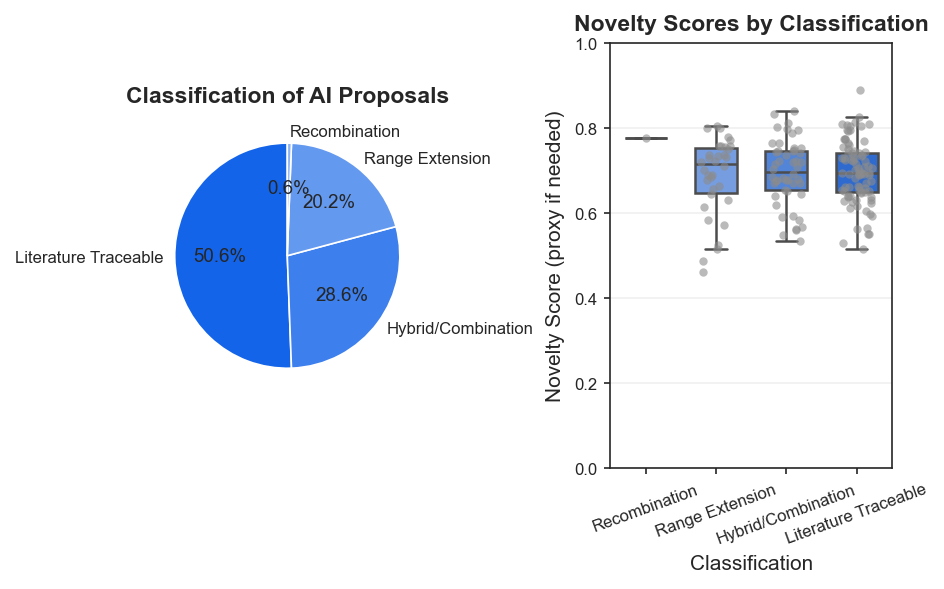

In [21]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=fw(4.0))

# Color palette: class_order sorted descending by median novelty score
# → index 0 = most novel (lightest blue), last index = least novel (darkest blue).
plot_df = test1_results.copy()
plot_df["novelty_for_plot"] = pd.to_numeric(plot_df["novelty_score_proxy"], errors="coerce")

class_order = (
    plot_df.groupby("classification")["novelty_for_plot"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

palette = [WHITE_SKY_CMAP(v) for v in np.linspace(0.45, 0.92, len(class_order))]
palette_map = dict(zip(class_order, palette))

# Pie chart with the same colormap colors (preserving value_counts order mapped to class_order).
pie_colors = [palette_map.get(lbl, WHITE_SKY_CMAP(0.8)) for lbl in classification_counts.index]
axes[0].pie(
    classification_counts.values,
    labels=classification_counts.index,
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Classification of AI Proposals", fontweight="bold")

# Boxplot: gradient from lightest blue (most novel) to darkest blue (least novel).
sns.boxplot(
    data=plot_df,
    x="classification",
    y="novelty_for_plot",
    order=class_order,
    hue="classification",
    hue_order=class_order,
    dodge=False,
    ax=axes[1],
    palette=palette_map,
    showfliers=False,
    width=0.6,
    linewidth=1.2,
    legend=False,
)

# Strip dots in neutral gray so they don't compete with box colors.
sns.stripplot(
    data=plot_df,
    x="classification",
    y="novelty_for_plot",
    order=class_order,
    ax=axes[1],
    color=SKY_WHITE_GRAY_CMAP(0.95),
    alpha=0.6,
    jitter=0.22,
    size=4,
)

axes[1].set_ylabel("Novelty Score (proxy if needed)")
axes[1].set_xlabel("Classification")
axes[1].set_title("Novelty Scores by Classification", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("results/test1/classification_summary.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.1b Calibrated Distance-to-Novelty Metrics

`1 - max_similarity` can be misleading on its own. This block calibrates novelty against the **known modality manifold** and reports how far each proposal is from a conservative novelty boundary.

In [15]:
# Calibrated novelty-distance metrics against known modalities.
if "training_embeddings" not in globals() or "proposal_embeddings" not in globals():
    raise RuntimeError(
        "Run the embedding cell in Section 4 first so training_embeddings and proposal_embeddings exist."
    )

if "test1_results" not in globals() or not isinstance(test1_results, pd.DataFrame):
    test1_results = pd.read_csv(path_test1_results)

# Similarity among known modalities (leave-one-out max similarity baseline).
sim_train_train = cosine_similarity(training_embeddings)
np.fill_diagonal(sim_train_train, -np.inf)
ref_max_sim = sim_train_train.max(axis=1)
ref_mean = float(np.mean(ref_max_sim))
ref_std = float(np.std(ref_max_sim, ddof=0))
q05 = float(np.quantile(ref_max_sim, 0.05))
q01 = float(np.quantile(ref_max_sim, 0.01))

# Proposal to known-modality similarities.
sim_prop_train = cosine_similarity(proposal_embeddings, training_embeddings)
prop_max_sim = sim_prop_train.max(axis=1)
prop_nn_dist = 1.0 - prop_max_sim

# Distance from conservative novelty boundaries.
# Positive gap => beyond the novelty boundary (more novel); negative => still inside known range.
gap_to_q05 = q05 - prop_max_sim
gap_to_q01 = q01 - prop_max_sim

# Empirical lower-tail probability under known-known baseline.
# Low p_tail means proposal similarity is unusually low relative to known modalities.
# Add +1 smoothing to avoid exact zero with small baseline size (n=8).
p_tail = np.array([(np.sum(ref_max_sim <= s) + 1) / (len(ref_max_sim) + 1) for s in prop_max_sim])

# Hull-violation magnitude (0 for inside hull).
if "outside_violation" in globals() and len(outside_violation) == len(test1_results):
    hull_violation = np.asarray(outside_violation, dtype=float)
elif "training_hull" in globals() and "proposal_emb_reduced" in globals():
    A = training_hull.equations[:, :-1]
    b = training_hull.equations[:, -1]
    vals = proposal_emb_reduced @ A.T + b
    hull_violation = np.maximum(vals, 0.0).max(axis=1)
else:
    hull_violation = np.zeros(len(test1_results), dtype=float)

# Merge into analysis table.
novelty_distance_df = test1_results.copy()
novelty_distance_df["prop_max_similarity"] = prop_max_sim
novelty_distance_df["prop_nn_distance"] = prop_nn_dist
novelty_distance_df["novelty_gap_q05"] = gap_to_q05
novelty_distance_df["novelty_gap_q01"] = gap_to_q01
novelty_distance_df["novelty_tail_p"] = p_tail
novelty_distance_df["hull_violation"] = hull_violation
novelty_distance_df["beyond_q05"] = novelty_distance_df["novelty_gap_q05"] > 0
novelty_distance_df["beyond_q01"] = novelty_distance_df["novelty_gap_q01"] > 0

# Optional composite distance score (rank-based, robust to scale mismatch).
rank_nn = novelty_distance_df["prop_nn_distance"].rank(pct=True)
rank_gap = novelty_distance_df["novelty_gap_q05"].rank(pct=True)
rank_hull = novelty_distance_df["hull_violation"].rank(pct=True)
novelty_distance_df["novelty_distance_score"] = (0.45 * rank_nn + 0.35 * rank_gap + 0.20 * rank_hull)

print("=== Calibrated Novelty Distance Summary ===")
print(f"Known-known max similarity baseline (n={len(ref_max_sim)}):")
print(f"  mean={ref_mean:.3f}, std={ref_std:.3f}, q05={q05:.3f}, q01={q01:.3f}")
print(f"Proposals beyond q05 novelty boundary: {novelty_distance_df['beyond_q05'].sum()} / {len(novelty_distance_df)}")
print(f"Proposals beyond q01 novelty boundary: {novelty_distance_df['beyond_q01'].sum()} / {len(novelty_distance_df)}")
print(f"Median novelty gap to q05: {novelty_distance_df['novelty_gap_q05'].median():.3f}")
print(f"Median lower-tail p-value: {novelty_distance_df['novelty_tail_p'].median():.3f}")

name_col = "proposal_name" if "proposal_name" in novelty_distance_df.columns else "closest_modality"
summary_cols = [
    c for c in [
        "model", "proposal_id", name_col,
        "prop_max_similarity", "prop_nn_distance", "novelty_gap_q05",
        "novelty_tail_p", "hull_violation", "novelty_distance_score",
        "beyond_q05", "beyond_q01",
    ] if c in novelty_distance_df.columns
]

print("\nTop-10 farthest from known manifold (higher novelty distance):")
display(
    novelty_distance_df[summary_cols]
    .sort_values(["novelty_distance_score", "novelty_gap_q05"], ascending=False)
    .head(10)
)

novelty_distance_out = Path("results/test1/novelty_distance_metrics.csv")
novelty_distance_df.to_csv(novelty_distance_out, index=False)
print(f"Saved calibrated metrics: {novelty_distance_out}")

=== Calibrated Novelty Distance Summary ===
Known-known max similarity baseline (n=8):
  mean=0.605, std=0.064, q05=0.507, q01=0.477
Proposals beyond q05 novelty boundary: 166 / 168
Proposals beyond q01 novelty boundary: 164 / 168
Median novelty gap to q05: 0.208
Median lower-tail p-value: 0.111

Top-10 farthest from known manifold (higher novelty distance):


,model,proposal_id,proposal_name,prop_max_similarity,prop_nn_distance,novelty_gap_q05,novelty_tail_p,hull_violation,novelty_distance_score,beyond_q05,beyond_q01
128,perplexity-sonar-pro,sample_128,Chronoreceptive Modality,0.110932,0.889068,0.396499,0.111111,0.0,0.900595,True,True
15,gemini-3.1-pro-preview,sample_015,Entropoception,0.159238,0.840762,0.348193,0.111111,0.0,0.895833,True,True
9,gemini-3.1-pro-preview,sample_009,Entropiception,0.166139,0.833861,0.341293,0.111111,0.0,0.891071,True,True
63,claude-3.7-sonnet,sample_063,Chronoception,0.173753,0.826247,0.333678,0.111111,0.0,0.886310,True,True
108,gemini-3.1-pro-preview,sample_108,Stochastiception,0.185689,0.814311,0.321742,0.111111,0.0,0.881548,True,True
96,gemini-3.1-pro-preview,sample_096,Entropoception,0.188815,0.811185,0.318616,0.111111,0.0,0.876786,True,True
89,claude-3.7-sonnet,sample_089,Chronoception,0.189762,0.810238,0.317670,0.111111,0.0,0.872024,True,True
118,gemini-3.1-pro-preview,sample_118,Entropioception,0.190553,0.809447,0.316879,0.111111,0.0,0.867262,True,True
92,claude-3.7-sonnet,sample_092,Chronoception,0.193066,0.806934,0.314366,0.111111,0.0,0.862500,True,True
151,gemini-3.1-pro-preview,sample_151,Entropiception,0.194133,0.805867,0.313298,0.111111,0.0,0.857738,True,True


Saved calibrated metrics: results/test1/novelty_distance_metrics.csv


In [16]:

def _modality_label(text: str) -> str:
    return str(text).replace("_", " ").strip().capitalize()


def plot_embedding_space(
    training_emb_reduced: np.ndarray,
    proposal_emb_reduced: np.ndarray,
    modalities: list[str],
    inside_hull: np.ndarray,
    save_path: str,
    membership_label: str = "3D PCA",
    annotate_proposals: bool = False,
) -> None:
    """2D PCA projection: training modalities and proposal points."""
    training_2d = training_emb_reduced[:, :2]
    proposal_2d = proposal_emb_reduced[:, :2]

    fig, ax = plt.subplots(figsize=fw(4.11))
    train_scatter = ax.scatter(
        training_2d[:, 0],
        training_2d[:, 1],
        s=MARKER_SIZE_L,
        c=BLUE_GRAY_RAMP[2],
        marker="o",
        alpha=0.7,
        edgecolors="black",
        linewidths=MARKER_EDGE_WIDTH,
        label="Training modalities",
    )

    for index, modality in enumerate(modalities):
        label = _modality_label(modality)
        ax.annotate(
            label,
            (training_2d[index, 0], training_2d[index, 1]),
            xytext=(8, 0),
            textcoords="offset points",
            fontsize=TICK_SIZE,
            fontweight="bold",
            ha="left",
            va="center",
            clip_on=True,
        )

    if len(training_2d) >= 3:
        for simplex in ConvexHull(training_2d).simplices:
            ax.plot(training_2d[simplex, 0], training_2d[simplex, 1], "k-", alpha=0.3, linewidth=1)

    colors = np.where(inside_hull.astype(bool), BLUE_GRAY_RAMP[4], BLUE_GRAY_RAMP[0])
    markers = np.where(inside_hull.astype(bool), "s", "^")

    for index in range(len(proposal_2d)):
        ax.scatter(
            proposal_2d[index, 0],
            proposal_2d[index, 1],
            s=MARKER_SIZE_M,
            c=colors[index],
            marker=markers[index],
            alpha=0.8,
            edgecolors="black",
            linewidths=MARKER_EDGE_WIDTH_STANDARD,
        )
        if annotate_proposals:
            ax.annotate(
                f"P{index + 1}",
                (proposal_2d[index, 0], proposal_2d[index, 1]),
                xytext=(8, 0),
                textcoords="offset points",
                fontsize=TICK_SIZE,
                fontweight="bold",
                ha="left",
                va="center",
                clip_on=True,
            )

    inside_handle = ax.scatter(
        [],
        [],
        s=MARKER_SIZE_M,
        c=BLUE_GRAY_RAMP[4],
        marker="s",
        edgecolors="black",
        linewidths=MARKER_EDGE_WIDTH_STANDARD,
        label=f"Proposals inside hull ({membership_label})",
    )
    outside_handle = ax.scatter(
        [],
        [],
        s=MARKER_SIZE_M,
        c=BLUE_GRAY_RAMP[0],
        marker="^",
        edgecolors="black",
        linewidths=MARKER_EDGE_WIDTH_STANDARD,
        label=f"Proposals outside hull ({membership_label})",
    )

    ax.legend(handles=[train_scatter, inside_handle, outside_handle], loc="upper right", fontsize=LEGEND_SIZE)
    ax.set_xlabel("PCA dim 1", fontsize=LABEL_SIZE)
    ax.set_ylabel("PCA dim 2", fontsize=LABEL_SIZE)
    ax.set_title(
        "Embedding Space (2D PCA Projection): Training Modalities vs AI Proposals",
        fontsize=TITLE_SIZE,
        fontweight="bold",
    )
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.18, y=0.18)

    plt.tight_layout()
    plt.savefig(save_path, dpi=320, bbox_inches="tight")
    print(f"Visualization saved to: {save_path}")
    plt.show()


def plot_embedding_space_3d(
    training_emb_reduced: np.ndarray,
    proposal_emb_reduced: np.ndarray,
    modalities: list[str],
    inside_hull_3d: np.ndarray,
    save_path: str,
) -> None:
    """True 3D PCA view with canonical 3D hull membership labels."""
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure(figsize=fw(4.11))
    ax = fig.add_subplot(111, projection="3d")

    training_z = training_emb_reduced[:, 2] if training_emb_reduced.shape[1] > 2 else np.zeros(len(training_emb_reduced))
    proposal_z = proposal_emb_reduced[:, 2] if proposal_emb_reduced.shape[1] > 2 else np.zeros(len(proposal_emb_reduced))

    ax.scatter(
        training_emb_reduced[:, 0],
        training_emb_reduced[:, 1],
        training_z,
        s=MARKER_SIZE_L,
        c=BLUE_GRAY_RAMP[2],
        marker="o",
        edgecolors="black",
        alpha=0.75,
        linewidths=MARKER_EDGE_WIDTH,
        label="Training modalities",
    )

    for index, modality in enumerate(modalities):
        ax.text(
            training_emb_reduced[index, 0],
            training_emb_reduced[index, 1],
            training_z[index],
            "  " + _modality_label(modality),
            fontsize=TICK_SIZE,
            weight="bold",
            ha="left",
            va="center",
        )

    inside_mask = inside_hull_3d.astype(bool)
    ax.scatter(
        proposal_emb_reduced[inside_mask, 0],
        proposal_emb_reduced[inside_mask, 1],
        proposal_z[inside_mask],
        s=MARKER_SIZE_M,
        c=BLUE_GRAY_RAMP[4],
        marker="s",
        alpha=0.85,
        edgecolors="black",
        linewidths=MARKER_EDGE_WIDTH_STANDARD,
        label="Proposals inside hull (3D PCA)",
    )
    ax.scatter(
        proposal_emb_reduced[~inside_mask, 0],
        proposal_emb_reduced[~inside_mask, 1],
        proposal_z[~inside_mask],
        s=MARKER_SIZE_S,
        c=BLUE_GRAY_RAMP[0],
        marker="^",
        alpha=0.75,
        edgecolors="black",
        linewidths=MARKER_EDGE_WIDTH_STANDARD,
        label="Proposals outside hull (3D PCA)",
    )

    ax.set_xlabel("PCA dim 1", fontsize=LABEL_SIZE)
    ax.set_ylabel("PCA dim 2", fontsize=LABEL_SIZE)
    ax.set_zlabel("PCA dim 3", fontsize=LABEL_SIZE)
    ax.set_title("3D PCA Embedding: Training Modalities vs AI Proposals", fontsize=TITLE_SIZE, fontweight="bold")
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.zaxis.set_tick_params(labelsize=TICK_SIZE)
    ax.legend(loc="best", fontsize=LEGEND_SIZE)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Visualization saved to: {save_path}")
    plt.show()


### 6.1c Distance-to-Novelty Dashboard

This dashboard visualizes how close proposals are to novelty under both calibrated manifold metrics and the rule-based frontier, with model-level comparisons and blocker composition.

rule_df is missing; using novelty_distance_df as fallback for dashboard metrics.


Saved Distance-to-Novelty Dashboard to: results/test1/novelty_distance_dashboard.png


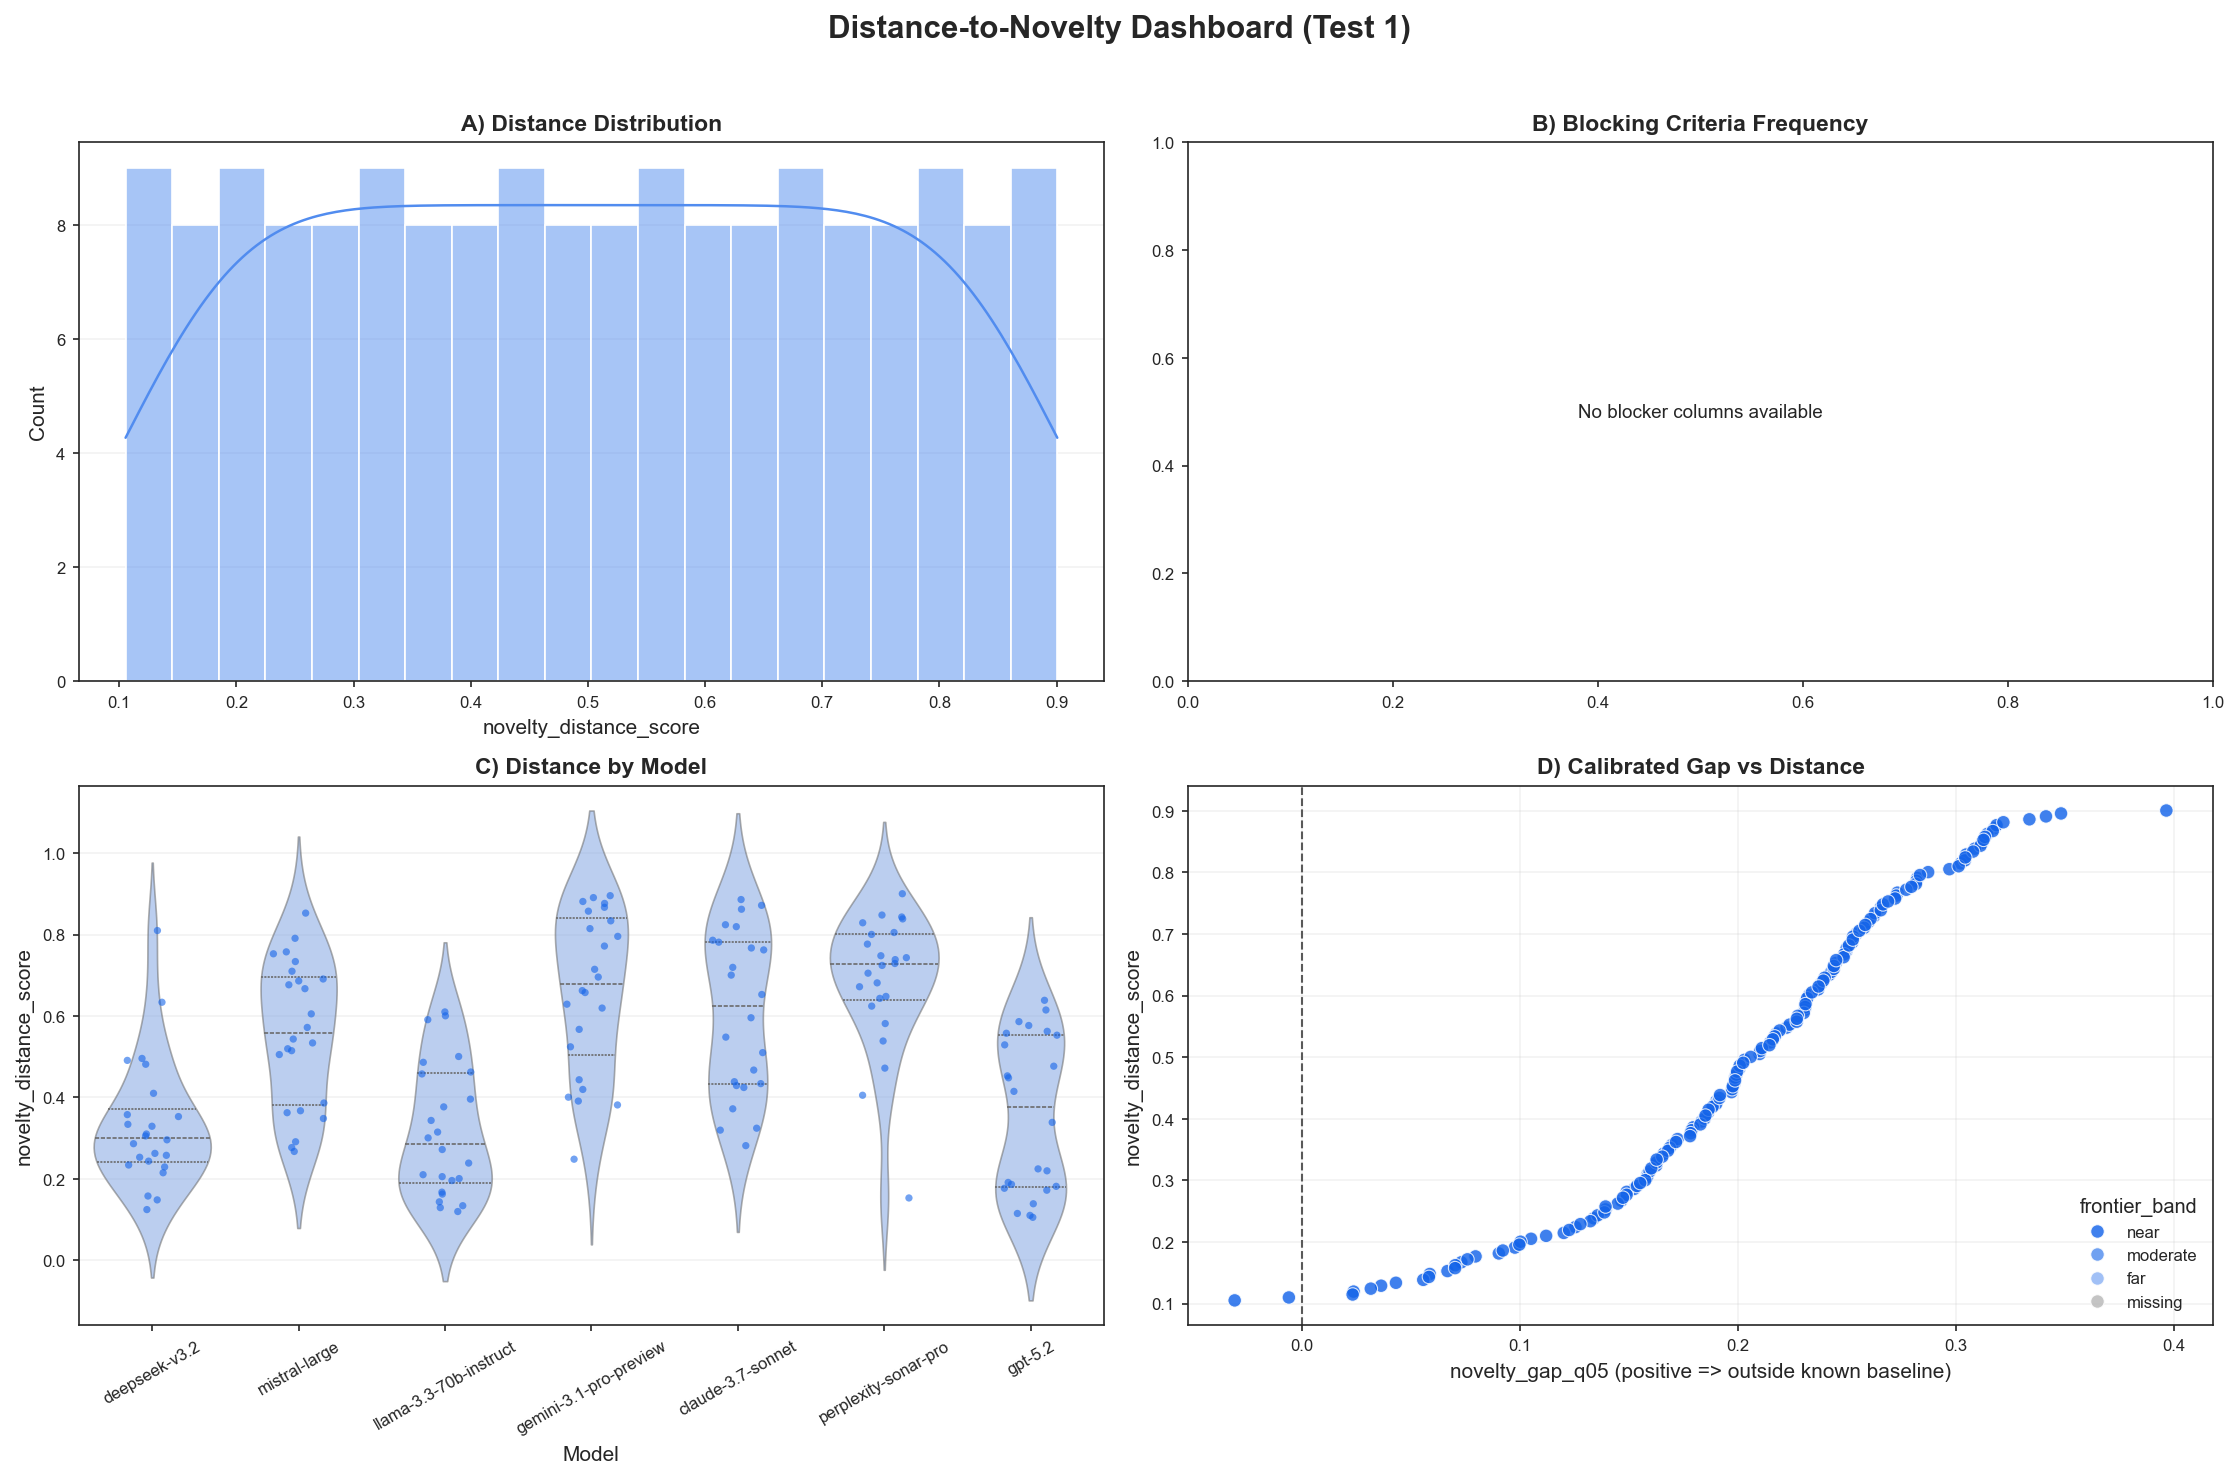

In [17]:
# Publication-ready dashboard for distance-to-novelty diagnostics.
if "novelty_distance_df" not in globals():
    raise RuntimeError("Run Section 6.1b first to create novelty_distance_df.")

if "rule_df" in globals() and isinstance(rule_df, pd.DataFrame):
    frontier_df = rule_df
else:
    frontier_df = novelty_distance_df.copy()
    print("rule_df is missing; using novelty_distance_df as fallback for dashboard metrics.")

dash_df = novelty_distance_df.copy()

# Merge frontier metrics from rule_df if not already present.
merge_cols = [
    c for c in [
        "proposal_id",
        "novelty_frontier_distance",
        "novelty_rule_violations",
        "violates_traceability",
        "violates_extension",
        "violates_hybrid",
        "violates_hull",
        "violates_similarity",
        "continuous_novelty_score",
    ]
    if c in frontier_df.columns
]
if "proposal_id" in merge_cols:
    dash_df = dash_df.merge(frontier_df[merge_cols], on="proposal_id", how="left", suffixes=("", "_rule"))
else:
    for c in merge_cols:
        if c not in dash_df.columns and c in frontier_df.columns:
            dash_df[c] = frontier_df[c].values

# Pick the best available distance metric so this dashboard works with or without rule_df.
distance_col = None
for candidate in ["novelty_frontier_distance", "novelty_distance_score"]:
    if candidate in dash_df.columns:
        distance_col = candidate
        break
if distance_col is None:
    raise KeyError("No distance column found. Expected one of: novelty_frontier_distance, novelty_distance_score.")

for bcol in [
    "violates_traceability",
    "violates_extension",
    "violates_hybrid",
    "violates_hull",
    "violates_similarity",
]:
    if bcol in dash_df.columns:
        dash_df[bcol] = dash_df[bcol].fillna(False).astype(bool)

# Robust numeric coercion for plotting.
for c in [
    "novelty_frontier_distance",
    "novelty_distance_score",
    "novelty_gap_q05",
    "prop_nn_distance",
    "hull_violation",
    "continuous_novelty_score",
]:
    if c in dash_df.columns:
        dash_df[c] = pd.to_numeric(dash_df[c], errors="coerce")

if "model" not in dash_df.columns:
    dash_df["model"] = "unknown"

dash_df["model"] = dash_df["model"].astype(str)
model_order = dash_df["model"].value_counts().index.tolist()

# Severity bands for quick interpretation of distance.
def _band_from_distance(x: float) -> str:
    if not np.isfinite(x):
        return "missing"
    if x <= 1.0:
        return "near"
    if x <= 2.0:
        return "moderate"
    return "far"

dash_df["frontier_band"] = dash_df[distance_col].apply(_band_from_distance)
band_order = ["near", "moderate", "far", "missing"]

# Unified colormap style: near (known boundary) = darkest blue, far (most novel) = lightest blue.
band_colors = {
    "near": WHITE_SKY_CMAP(0.92),
    "moderate": WHITE_SKY_CMAP(0.68),
    "far": WHITE_SKY_CMAP(0.45),
    "missing": SKY_WHITE_GRAY_CMAP(0.78),
}

# Figure 1: 2x2 dashboard.
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Distance-to-Novelty Dashboard (Test 1)", fontsize=15, fontweight="bold")

# Panel A: Distance distribution.
sns.histplot(
    data=dash_df,
    x=distance_col,
    bins=20,
    kde=True,
    color=WHITE_SKY_CMAP(0.68),
    ax=axes[0, 0],
)
axes[0, 0].set_title("A) Distance Distribution")
axes[0, 0].set_xlabel(distance_col)
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(axis="y", alpha=0.25)

# Panel B: Blocker composition.
blocker_cols = [
    c
    for c in [
        "violates_traceability",
        "violates_hull",
        "violates_hybrid",
        "violates_extension",
        "violates_similarity",
    ]
    if c in dash_df.columns
]
blocker_share = (
    dash_df[blocker_cols].mean().sort_values(ascending=False) if blocker_cols else pd.Series(dtype=float)
)
if len(blocker_share):
    blocker_labels = [s.replace("violates_", "") for s in blocker_share.index]
    blocker_palette = [WHITE_SKY_CMAP(v) for v in np.linspace(0.92, 0.50, len(blocker_share))]
    sns.barplot(
        x=blocker_share.values * 100.0,
        y=blocker_labels,
        hue=blocker_labels,
        palette=blocker_palette,
        dodge=False,
        legend=False,
        ax=axes[0, 1],
    )
    axes[0, 1].set_xlim(0, 100)
    axes[0, 1].set_title("B) Blocking Criteria Frequency")
    axes[0, 1].set_xlabel("Rows blocked (%)")
    axes[0, 1].set_ylabel("Criterion")
else:
    axes[0, 1].text(0.5, 0.5, "No blocker columns available", ha="center", va="center")
    axes[0, 1].set_title("B) Blocking Criteria Frequency")

# Panel C: By-model distance — violin + band-colored strip.
sns.violinplot(
    data=dash_df,
    x="model",
    y=distance_col,
    order=model_order,
    color=WHITE_SKY_CMAP(0.55),
    inner="quartile",
    linewidth=0.8,
    alpha=0.55,
    ax=axes[1, 0],
)
sns.stripplot(
    data=dash_df,
    x="model",
    y=distance_col,
    order=model_order,
    hue="frontier_band",
    hue_order=band_order,
    palette=band_colors,
    alpha=0.6,
    jitter=0.18,
    size=3.5,
    ax=axes[1, 0],
    legend=False,
)
axes[1, 0].set_title("C) Distance by Model")
axes[1, 0].set_xlabel("Model")
axes[1, 0].set_ylabel(distance_col)
axes[1, 0].tick_params(axis="x", rotation=30)
axes[1, 0].grid(axis="y", alpha=0.25)

# Panel D: Calibrated manifold distance vs selected distance metric.
if "novelty_gap_q05" in dash_df.columns:
    sns.scatterplot(
        data=dash_df,
        x="novelty_gap_q05",
        y=distance_col,
        hue="frontier_band",
        hue_order=band_order,
        palette=band_colors,
        alpha=0.82,
        s=42,
        ax=axes[1, 1],
    )
    axes[1, 1].axvline(0.0, ls="--", lw=1, color="0.35")
    axes[1, 1].set_title("D) Calibrated Gap vs Distance")
    axes[1, 1].set_xlabel("novelty_gap_q05 (positive => outside known baseline)")
    axes[1, 1].set_ylabel(distance_col)
    axes[1, 1].grid(alpha=0.25)
else:
    axes[1, 1].text(0.5, 0.5, "novelty_gap_q05 not available", ha="center", va="center")
    axes[1, 1].set_title("D) Calibrated Gap vs Distance")

plt.tight_layout(rect=[0, 0, 1, 0.96])

out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
dashboard_png = out_dir / "novelty_distance_dashboard.png"
print(f"Saved Distance-to-Novelty Dashboard to: {dashboard_png}")
plt.savefig(dashboard_png, dpi=320, bbox_inches="tight")
plt.show()


Saved Frontier Bands by Model to: results/test1/novelty_frontier_bands_by_model.png
Saved Continuous Novelty Score Histogram to: results/test1/continuous_novelty_score_histogram.png


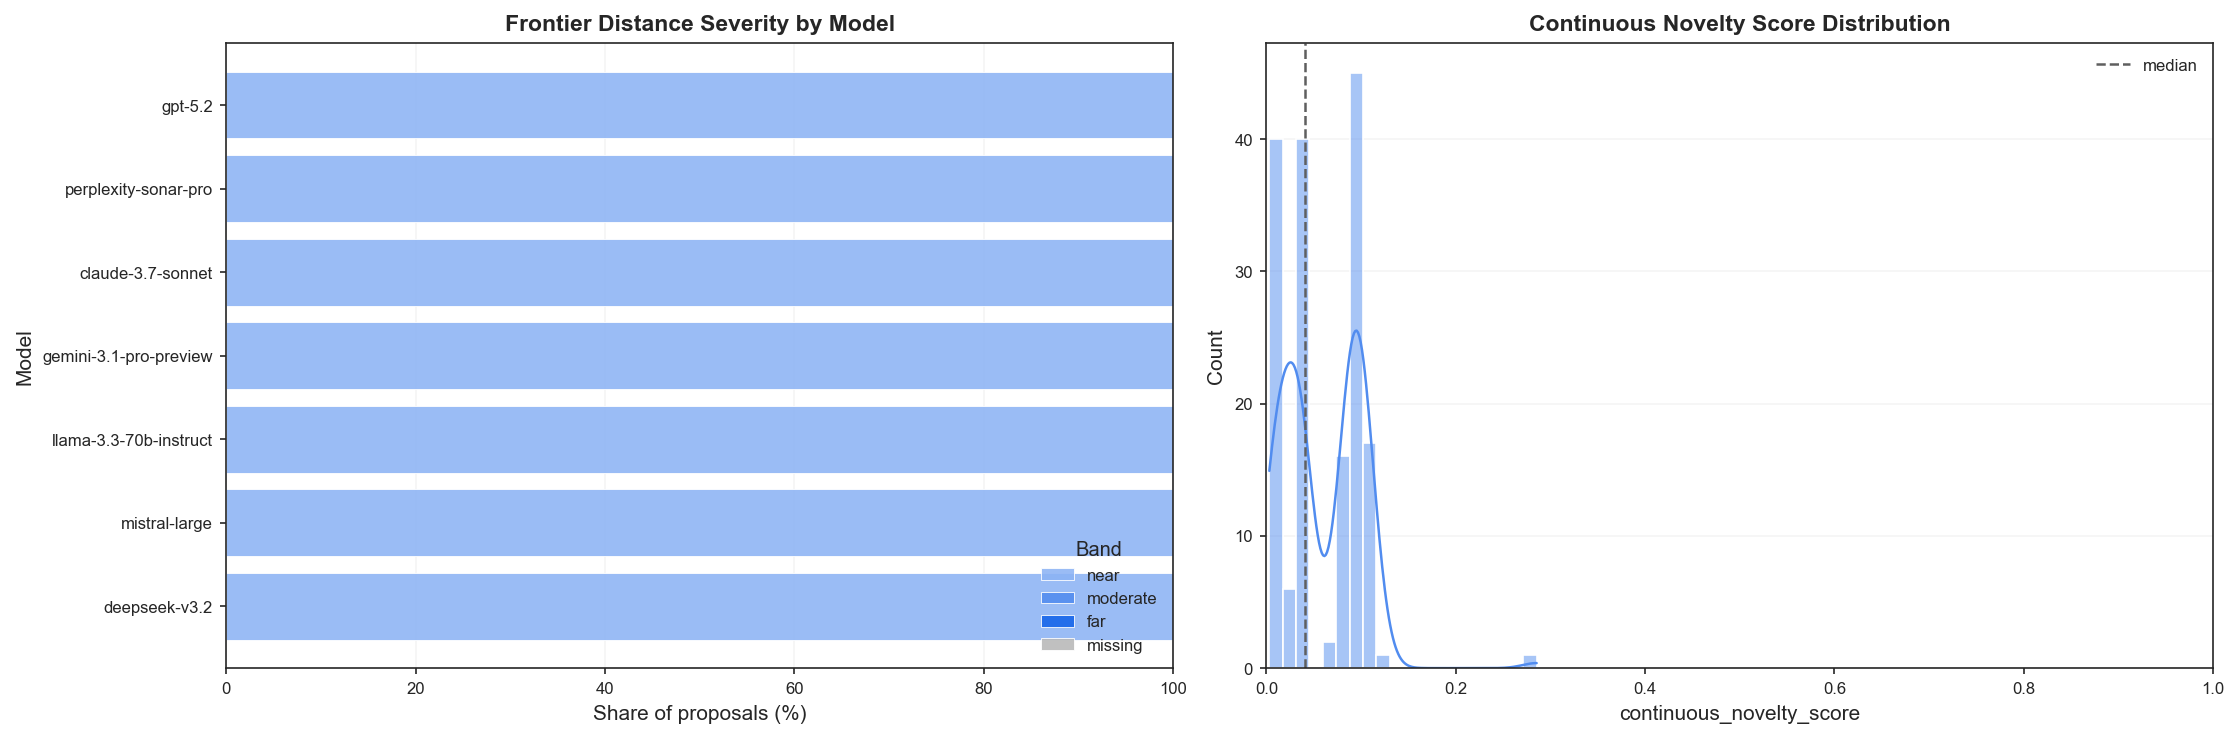

In [18]:
# Figure 2 + Figure 3 combined: parallel subplots (1 row, 2 columns).
band_order = ["near", "moderate", "far", "missing"]
band_ct = pd.crosstab(dash_df["model"], dash_df["frontier_band"]).reindex(model_order).fillna(0)
for b in band_order:
    if b not in band_ct.columns:
        band_ct[b] = 0
band_ct = band_ct[band_order]
band_pct = band_ct.div(band_ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100.0

fig23, (ax2, ax3) = plt.subplots(
    1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.0, 1.0]}
)

# Same colormap logic as recent figures: blue intensity + gray for missing.
colors = {
    "near": WHITE_SKY_CMAP(0.45),
    "moderate": WHITE_SKY_CMAP(0.68),
    "far": WHITE_SKY_CMAP(0.92),
    "missing": SKY_WHITE_GRAY_CMAP(0.78),
}

# Left panel: stacked frontier bands by model.
left = np.zeros(len(band_pct))
for b in band_order:
    vals = band_pct[b].to_numpy()
    ax2.barh(
        band_pct.index,
        vals,
        left=left,
        color=colors[b],
        label=b,
        alpha=0.88,
        edgecolor="#ffffff",
        linewidth=0.45,
    )
    left += vals

ax2.set_xlim(0, 100)
ax2.set_xlabel("Share of proposals (%)")
ax2.set_ylabel("Model")
ax2.set_title("Frontier Distance Severity by Model", fontweight="bold")
ax2.legend(title="Band", loc="lower right")
ax2.grid(axis="x", alpha=0.2)

# Right panel: continuous novelty score distribution.
score_hist_png = None
if "continuous_novelty_score" in dash_df.columns and dash_df["continuous_novelty_score"].notna().any():
    sns.histplot(
        data=dash_df,
        x="continuous_novelty_score",
        bins=20,
        kde=True,
        color=WHITE_SKY_CMAP(0.68),
        ax=ax3,
    )
    ax3.axvline(
        float(dash_df["continuous_novelty_score"].median()),
        color=THRESHOLD_COLOR,
        linestyle="--",
        linewidth=1.2,
        label="median",
    )
    ax3.set_xlim(0, 1)
    ax3.set_title("Continuous Novelty Score Distribution", fontweight="bold")
    ax3.set_xlabel("continuous_novelty_score")
    ax3.set_ylabel("Count")
    ax3.legend(loc="upper right")
    ax3.grid(axis="y", alpha=0.2)
else:
    ax3.text(0.5, 0.5, "continuous_novelty_score not available", ha="center", va="center")
    ax3.set_title("Continuous Novelty Score Distribution", fontweight="bold")
    ax3.set_xlabel("continuous_novelty_score")
    ax3.set_ylabel("Count")

plt.tight_layout()

bands_png = out_dir / "novelty_frontier_bands_by_model.png"
score_hist_png = out_dir / "continuous_novelty_score_histogram.png"
plt.savefig(bands_png, dpi=320, bbox_inches="tight")
print(f"Saved Frontier Bands by Model to: {bands_png}")
plt.savefig(score_hist_png, dpi=320, bbox_inches="tight")
print(f"Saved Continuous Novelty Score Histogram to: {score_hist_png}")
plt.show()

In [19]:
# Export compact summary table for the paper text.
summary_rows = []
for m in model_order:
    g = dash_df[dash_df["model"] == m]
    summary_rows.append(
        {
            "model": m,
            "n": int(len(g)),
            "frontier_distance_mean": float(pd.to_numeric(g["novelty_frontier_distance"], errors="coerce").mean()),
            "frontier_distance_median": float(pd.to_numeric(g["novelty_frontier_distance"], errors="coerce").median()),
            "continuous_novelty_score_mean": float(pd.to_numeric(g.get("continuous_novelty_score", np.nan), errors="coerce").mean()),
            "continuous_novelty_score_median": float(pd.to_numeric(g.get("continuous_novelty_score", np.nan), errors="coerce").median()),
            "gap_q05_median": float(pd.to_numeric(g.get("novelty_gap_q05", np.nan), errors="coerce").median()),
            "blocked_traceability_pct": float(g["violates_traceability"].mean() * 100.0) if "violates_traceability" in g else np.nan,
            "blocked_hull_pct": float(g["violates_hull"].mean() * 100.0) if "violates_hull" in g else np.nan,
            "blocked_hybrid_pct": float(g["violates_hybrid"].mean() * 100.0) if "violates_hybrid" in g else np.nan,
            "blocked_extension_pct": float(g["violates_extension"].mean() * 100.0) if "violates_extension" in g else np.nan,
        }
    )

novelty_dashboard_summary = pd.DataFrame(summary_rows)
summary_csv = out_dir / "novelty_distance_dashboard_summary_by_model.csv"
novelty_dashboard_summary.to_csv(summary_csv, index=False)

print("Saved novelty dashboard outputs:")
print(f" - {dashboard_png}")
print(f" - {bands_png}")
if score_hist_png is not None:
    print(f" - {score_hist_png}")
print(f" - {summary_csv}")
display(novelty_dashboard_summary)

KeyError: 'novelty_frontier_distance'

### 6.1c.1 Continuous Novelty Score by Model

Add a compact model-level view of `continuous_novelty_score` and generate a short manuscript-ready interpretation paragraph based on the latest values.

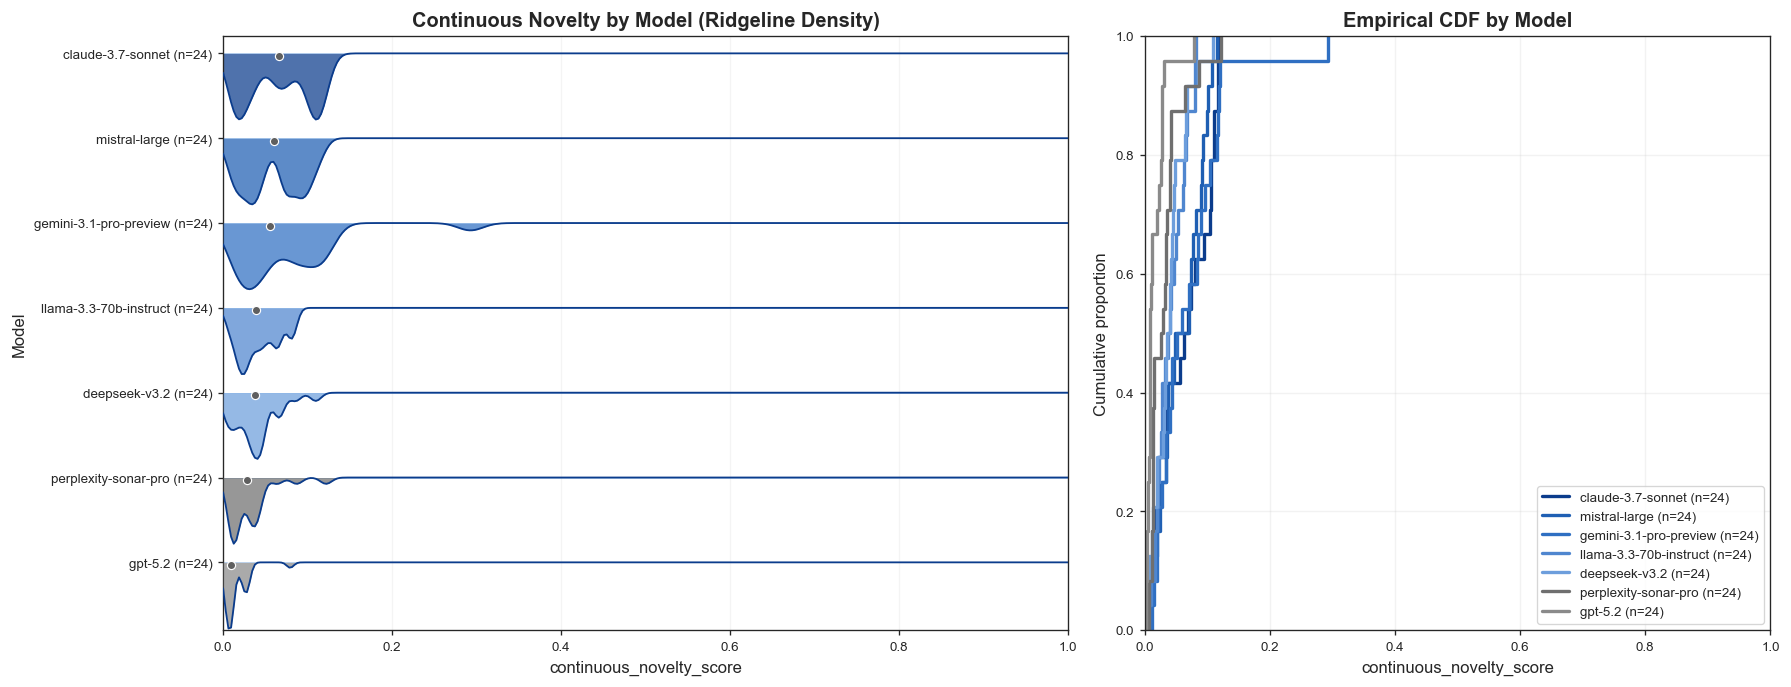

Saved by-model score plot: results/test1/continuous_novelty_score_by_model.png
Saved interpretation paragraph: results/test1/continuous_novelty_score_paragraph.txt

=== Continuous Novelty Score Interpretation ===
The continuous novelty score remained low overall, with a median of 0.035 and mean of 0.046, indicating that most Test 1 proposals stayed far from the study's effective novelty boundary even when semantic distance from known modalities was non-zero. At the model level, claude-3.7-sonnet showed the highest median continuous novelty score (0.066), whereas gpt-5.2 showed the lowest (0.009). This pattern is consistent with the frontier analysis: differences across models exist, but all models remain heavily constrained by structural blockers such as hull membership and traceability.


,model,mean,median,std,count
0,claude-3.7-sonnet,0.0648,0.0661,0.0407,24
1,mistral-large,0.0592,0.0597,0.0339,24
2,gemini-3.1-pro-preview,0.0717,0.0558,0.0599,24
3,llama-3.3-70b-instruct,0.0418,0.0387,0.0233,24
4,deepseek-v3.2,0.0395,0.0378,0.0259,24
5,perplexity-sonar-pro,0.0321,0.0279,0.0271,24
6,gpt-5.2,0.0158,0.0094,0.0164,24


In [ ]:
# Model-level view of the continuous novelty score plus a compact interpretation paragraph.
from scipy.stats import gaussian_kde

if "dash_df" not in globals() or not isinstance(dash_df, pd.DataFrame):
    if "rule_df" in globals() and isinstance(rule_df, pd.DataFrame):
        dash_df = rule_df.copy()
    else:
        raise RuntimeError("Run the main dashboard cell first so dash_df or rule_df exists.")

plot_score_df = dash_df.copy()
if "continuous_novelty_score" not in plot_score_df.columns:
    raise KeyError("continuous_novelty_score is missing. Run the frontier-distance cell first.")

plot_score_df["continuous_novelty_score"] = pd.to_numeric(
    plot_score_df["continuous_novelty_score"], errors="coerce"
).clip(lower=0.0, upper=1.0)
plot_score_df = plot_score_df.dropna(subset=["continuous_novelty_score"]).copy()

if "model" not in plot_score_df.columns:
    plot_score_df["model"] = "unknown"
plot_score_df["model"] = plot_score_df["model"].astype(str)

model_order_score = (
    plot_score_df.groupby("model")["continuous_novelty_score"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Two-panel distribution view: ridgeline density + ECDF for shape and tail diagnostics.
fig, (ax_dist, ax_ecdf) = plt.subplots(
    1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [1.35, 1.0]}
 )

palette_score = MODEL_VISIBLE_COLORS[:len(model_order_score)]
x_grid = np.linspace(0, 1, 320)

for i, model_name in enumerate(model_order_score):
    vals = plot_score_df.loc[plot_score_df["model"] == model_name, "continuous_novelty_score"].dropna()
    n_vals = len(vals)

    if n_vals == 0:
        continue

    if n_vals >= 2 and vals.nunique() > 1:
        kde = gaussian_kde(vals.to_numpy(), bw_method=0.25)
        dens = kde(x_grid)
    else:
        center = float(vals.iloc[0])
        dens = np.exp(-0.5 * ((x_grid - center) / 0.03) ** 2)

    max_d = float(np.max(dens)) if len(dens) else 0.0
    dens_norm = dens / max_d if max_d > 0 else dens
    ridge_height = 0.78
    ridge_y = i + ridge_height * dens_norm

    ax_dist.fill_between(
        x_grid, i, ridge_y,
        color=palette_score[i],
        alpha=0.72,
        linewidth=0,
        zorder=2 + i,
    )
    ax_dist.plot(x_grid, ridge_y, color=BLUE_GRAY_RAMP[0], linewidth=1.1, zorder=3 + i)
    ax_dist.hlines(i, 0, 1, color=BLUE_GRAY_RAMP[2], linewidth=0.6, alpha=0.45, zorder=1)

    med = float(vals.median())
    ax_dist.scatter(
        med,
        i + 0.03,
        color=THRESHOLD_COLOR,
        edgecolor="white",
        linewidth=0.7,
        s=24,
        zorder=10,
    )

ax_dist.set_title("Continuous Novelty by Model (Ridgeline Density)", fontweight="bold")
ax_dist.set_xlabel("continuous_novelty_score")
ax_dist.set_ylabel("Model")
ax_dist.set_xlim(0, 1)
ax_dist.set_ylim(-0.2, max(len(model_order_score) - 0.2, 0.8))
ax_dist.set_yticks(range(len(model_order_score)))
ax_dist.set_yticklabels([f"{m} (n={int((plot_score_df['model'] == m).sum())})" for m in model_order_score])
ax_dist.grid(axis="x", alpha=0.2)
ax_dist.invert_yaxis()

for i, model_name in enumerate(model_order_score):
    vals = plot_score_df.loc[plot_score_df["model"] == model_name, "continuous_novelty_score"].dropna()
    if len(vals) == 0:
        continue
    sns.ecdfplot(
        vals,
        ax=ax_ecdf,
        color=palette_score[i],
        linewidth=2,
        label=f"{model_name} (n={len(vals)})",
    )

ax_ecdf.set_title("Empirical CDF by Model", fontweight="bold")
ax_ecdf.set_xlabel("continuous_novelty_score")
ax_ecdf.set_ylabel("Cumulative proportion")
ax_ecdf.set_xlim(0, 1)
ax_ecdf.set_ylim(0, 1)
ax_ecdf.grid(alpha=0.25)
ax_ecdf.legend(loc="lower right", fontsize=8, frameon=True)

plt.tight_layout()

out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
score_by_model_png = out_dir / "continuous_novelty_score_by_model.png"
plt.savefig(score_by_model_png, dpi=320, bbox_inches="tight")
plt.show()

score_summary = (
    plot_score_df.groupby("model")["continuous_novelty_score"]
    .agg(["mean", "median", "std", "count"])
.sort_values("median", ascending=False)
    .reset_index()
)

top_model = score_summary.iloc[0]
bottom_model = score_summary.iloc[-1]
overall_median = float(plot_score_df["continuous_novelty_score"].median())
overall_mean = float(plot_score_df["continuous_novelty_score"].mean())

interpretation_text = (
    "The continuous novelty score remained low overall, with a median of "
    f"{overall_median:.3f} and mean of {overall_mean:.3f}, indicating that most Test 1 proposals stayed far from the study's "
    "effective novelty boundary even when semantic distance from known modalities was non-zero. "
    f"At the model level, {top_model['model']} showed the highest median continuous novelty score "
    f"({top_model['median']:.3f}), whereas {bottom_model['model']} showed the lowest ({bottom_model['median']:.3f}). "
    "This pattern is consistent with the frontier analysis: differences across models exist, but all models remain heavily "
    "constrained by structural blockers such as hull membership and traceability."
)

text_path = out_dir / "continuous_novelty_score_paragraph.txt"
with text_path.open("w", encoding="utf-8") as f:
    f.write(interpretation_text + "\n")

print(f"Saved by-model score plot: {score_by_model_png}")
print(f"Saved interpretation paragraph: {text_path}")
print("\n=== Continuous Novelty Score Interpretation ===")
print(interpretation_text)
display(score_summary.round(4))

### 6.1d Frontier Distance Decomposition by Criterion

Decompose `novelty_frontier_distance` into additive components to quantify which criteria drive non-novel decisions for each model.

Max reconstruction delta vs novelty_frontier_distance: 0.000e+00


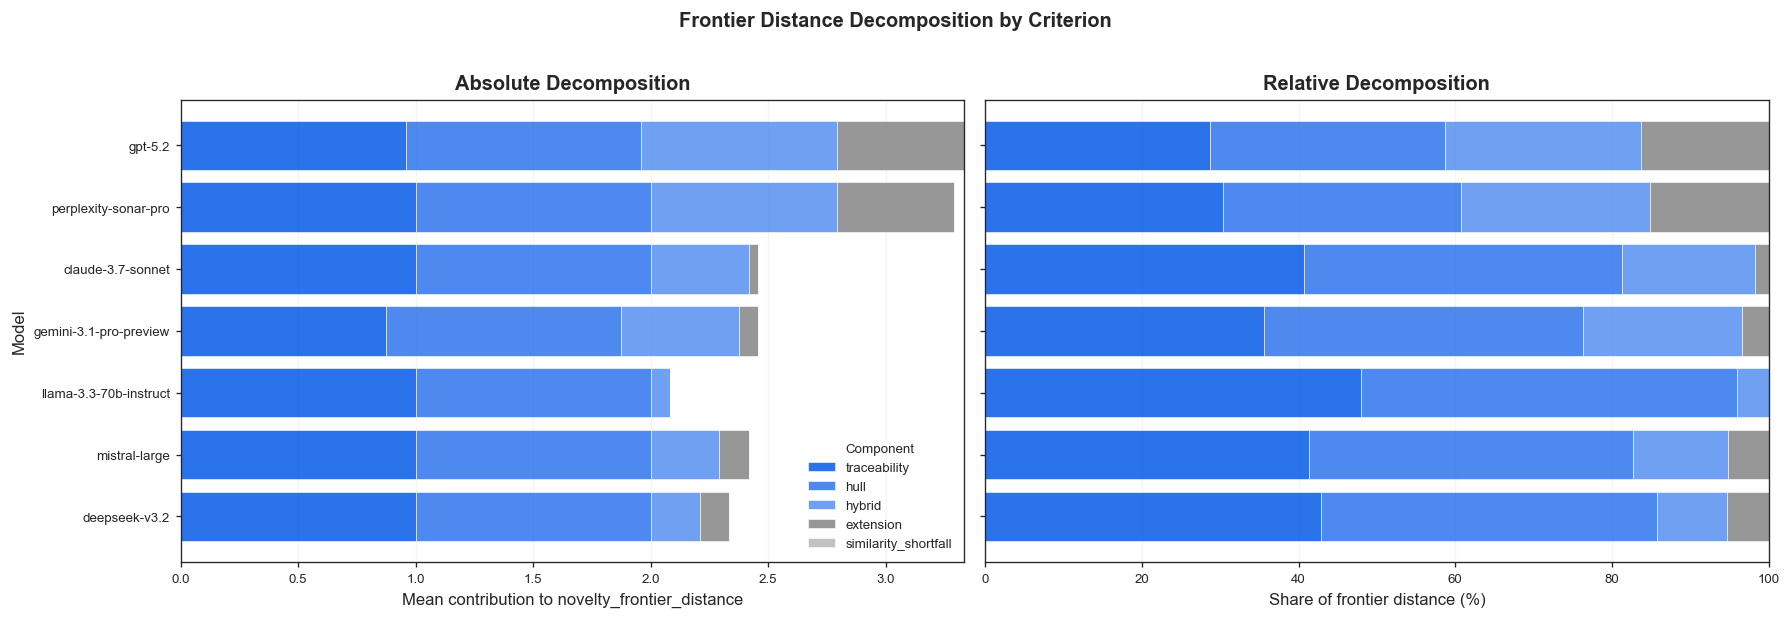

Saved decomposition outputs:
 - results/test1/novelty_frontier_decomposition_by_model_combined.png
 - results/test1/novelty_frontier_contribution_by_model.csv


,model,abs_traceability,abs_hull,abs_hybrid,abs_extension,abs_similarity_shortfall,pct_traceability,pct_hull,pct_hybrid,pct_extension,pct_similarity_shortfall
0,deepseek-v3.2,1.000000,1.0,0.208333,0.125000,0.0,42.857143,42.857143,8.928571,5.357143,0.0
1,mistral-large,1.000000,1.0,0.291667,0.125000,0.0,41.379310,41.379310,12.068966,5.172414,0.0
2,llama-3.3-70b-instruct,1.000000,1.0,0.083333,0.000000,0.0,48.000000,48.000000,4.000000,0.000000,0.0
3,gemini-3.1-pro-preview,0.875000,1.0,0.500000,0.083333,0.0,35.593220,40.677966,20.338983,3.389831,0.0
4,claude-3.7-sonnet,1.000000,1.0,0.416667,0.041667,0.0,40.677966,40.677966,16.949153,1.694915,0.0
5,perplexity-sonar-pro,1.000000,1.0,0.791667,0.500000,0.0,30.379747,30.379747,24.050633,15.189873,0.0
6,gpt-5.2,0.958333,1.0,0.833333,0.541667,0.0,28.750000,30.000000,25.000000,16.250000,0.0


In [ ]:
# Decompose novelty_frontier_distance into additive criterion components.
if "rule_df" not in globals() or not isinstance(rule_df, pd.DataFrame):
    raise RuntimeError("Run the frontier-distance cell first to create rule_df.")

decomp_df = rule_df.copy()
if "model" not in decomp_df.columns:
    decomp_df["model"] = "unknown"
decomp_df["model"] = decomp_df["model"].astype(str)
model_order = decomp_df["model"].value_counts().index.tolist()

# Rebuild component terms exactly as used in novelty_frontier_distance.
sim_threshold = NOVELTY_FRONTIER_SIM_THRESHOLD
max_sim = pd.to_numeric(decomp_df.get("max_similarity", np.nan), errors="coerce")
if max_sim.isna().all() and "prop_max_similarity" in decomp_df.columns:
    max_sim = pd.to_numeric(decomp_df["prop_max_similarity"], errors="coerce")
sim_margin = sim_threshold - max_sim
sim_shortfall_component = np.maximum(0.0, -sim_margin) / sim_threshold

decomp_df["comp_similarity_shortfall"] = sim_shortfall_component

def _bool_component(col: str) -> pd.Series:
    if col in decomp_df.columns:
        return decomp_df[col].fillna(False).astype(bool).astype(float)
    return pd.Series(np.zeros(len(decomp_df)), index=decomp_df.index, dtype=float)

decomp_df["comp_traceability"] = _bool_component("is_traceable")
decomp_df["comp_hull"] = _bool_component("inside_convex_hull")
decomp_df["comp_hybrid"] = _bool_component("is_hybrid")
decomp_df["comp_extension"] = _bool_component("is_extension")

component_cols = [
    "comp_traceability",
    "comp_hull",
    "comp_hybrid",
    "comp_extension",
    "comp_similarity_shortfall",
]

# Consistency check with previously computed novelty_frontier_distance.
decomp_df["frontier_distance_rebuilt"] = decomp_df[component_cols].sum(axis=1)
if "novelty_frontier_distance" in decomp_df.columns:
    max_delta = float(np.nanmax(np.abs(decomp_df["frontier_distance_rebuilt"] - decomp_df["novelty_frontier_distance"])))
    print(f"Max reconstruction delta vs novelty_frontier_distance: {max_delta:.3e}")

# Per-model mean contribution (absolute units in frontier-distance points).
contrib_abs = (
    decomp_df.groupby("model")[component_cols]
    .mean()
    .reindex(model_order)
)

# Relative contribution share (% of total mean frontier distance).
row_sum = contrib_abs.sum(axis=1).replace(0.0, np.nan)
contrib_pct = contrib_abs.div(row_sum, axis=0).fillna(0.0) * 100.0

# Human-readable output table.
rename_map = {
    "comp_traceability": "traceability",
    "comp_hull": "hull",
    "comp_hybrid": "hybrid",
    "comp_extension": "extension",
    "comp_similarity_shortfall": "similarity_shortfall",
}
contrib_abs_disp = contrib_abs.rename(columns=rename_map)
contrib_pct_disp = contrib_pct.rename(columns=rename_map)

decomposition_table = contrib_abs_disp.add_prefix("abs_")
for column in contrib_pct_disp.columns:
    decomposition_table[f"pct_{column}"] = contrib_pct_disp[column]

decomposition_table = decomposition_table.reset_index()

# Plot both decomposition views in parallel (1 row, 2 columns).
plot_order = ["traceability", "hull", "hybrid", "extension", "similarity_shortfall"]

# Requested order (darkest -> lightest): traceability, hull, hybrid, extension(gray), similarity_shortfall(light-gray).
colors = {
    "traceability": WHITE_SKY_CMAP(0.98),
    "hull": WHITE_SKY_CMAP(0.82),
    "hybrid": WHITE_SKY_CMAP(0.66),
    "extension": SKY_WHITE_GRAY_CMAP(0.98),
    "similarity_shortfall": SKY_WHITE_GRAY_CMAP(0.78),
}

fig, (ax_abs, ax_pct) = plt.subplots(1, 2, figsize=fw(4.11), sharey=True)

# Left: stacked absolute contributions.
left_abs = np.zeros(len(contrib_abs_disp))
y_labels = contrib_abs_disp.index.tolist()
for key in plot_order:
    values = contrib_abs_disp[key].to_numpy() if key in contrib_abs_disp.columns else np.zeros(len(contrib_abs_disp))
    ax_abs.barh(
        y_labels,
        values,
        left=left_abs,
        label=key,
        color=colors.get(key, "#999999"),
        alpha=0.85,
        edgecolor="#ffffff",
        linewidth=0.4,
    )
    left_abs += values

ax_abs.set_xlabel("Mean contribution to novelty_frontier_distance", fontsize=LABEL_SIZE)
ax_abs.set_ylabel("Model", fontsize=LABEL_SIZE)
ax_abs.set_title("Absolute Decomposition", fontsize=TITLE_SIZE, fontweight="bold")
ax_abs.tick_params(axis="both", labelsize=TICK_SIZE)
ax_abs.grid(axis="x", alpha=0.2)
ax_abs.legend(title="Component", loc="lower right", fontsize=LEGEND_SIZE, title_fontsize=LEGEND_SIZE)

# Right: stacked percentage shares.
left_pct = np.zeros(len(contrib_pct_disp))
y_labels_pct = contrib_pct_disp.index.tolist()
for key in plot_order:
    values = contrib_pct_disp[key].to_numpy() if key in contrib_pct_disp.columns else np.zeros(len(contrib_pct_disp))
    ax_pct.barh(
        y_labels_pct,
        values,
        left=left_pct,
        label=key,
        color=colors.get(key, "#999999"),
        alpha=0.85,
        edgecolor="#ffffff",
        linewidth=0.4,
    )
    left_pct += values

ax_pct.set_xlim(0, 100)
ax_pct.set_xlabel("Share of frontier distance (%)", fontsize=LABEL_SIZE)
ax_pct.set_title("Relative Decomposition", fontsize=TITLE_SIZE, fontweight="bold")
ax_pct.tick_params(axis="both", labelsize=TICK_SIZE)
ax_pct.grid(axis="x", alpha=0.2)

plt.suptitle("Frontier Distance Decomposition by Criterion", y=1.02, fontsize=TITLE_SIZE, fontweight="bold")
plt.tight_layout()

out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
fig_path_combined = out_dir / "novelty_frontier_decomposition_by_model_combined.png"
plt.savefig(fig_path_combined, dpi=320, bbox_inches="tight")
plt.show()

csv_path = out_dir / "novelty_frontier_contribution_by_model.csv"
decomposition_table.to_csv(csv_path, index=False)

print("Saved decomposition outputs:")
print(f" - {fig_path_combined}")
print(f" - {csv_path}")
display(decomposition_table)

### 6.1e Auto-Generated Results Paragraph (Draft)

Generate manuscript-ready summary text directly from decomposition outputs to keep narrative synchronized with the latest computations.

In [ ]:
# Auto-generate a manuscript-ready Results paragraph from computed decomposition metrics.
if "decomposition_table" not in globals() or not isinstance(decomposition_table, pd.DataFrame):
    raise RuntimeError("Run the decomposition cell first to create decomposition_table.")

res_df = decomposition_table.copy()

required_cols = [
    "model",
    "abs_traceability",
    "abs_hull",
    "abs_hybrid",
    "abs_extension",
    "abs_similarity_shortfall",
]
missing_cols = [c for c in required_cols if c not in res_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns for paragraph generation: {missing_cols}")

# Total mean frontier distance per model.
res_df["frontier_mean"] = (
    pd.to_numeric(res_df["abs_traceability"], errors="coerce")
    + pd.to_numeric(res_df["abs_hull"], errors="coerce")
    + pd.to_numeric(res_df["abs_hybrid"], errors="coerce")
    + pd.to_numeric(res_df["abs_extension"], errors="coerce")
    + pd.to_numeric(res_df["abs_similarity_shortfall"], errors="coerce")
)

ranked = res_df.sort_values("frontier_mean", ascending=False).reset_index(drop=True)

top_model = ranked.iloc[0]
bottom_model = ranked.iloc[-1]

overall_means = {
    "traceability": float(pd.to_numeric(res_df["abs_traceability"], errors="coerce").mean()),
    "hull": float(pd.to_numeric(res_df["abs_hull"], errors="coerce").mean()),
    "hybrid": float(pd.to_numeric(res_df["abs_hybrid"], errors="coerce").mean()),
    "extension": float(pd.to_numeric(res_df["abs_extension"], errors="coerce").mean()),
    "similarity_shortfall": float(pd.to_numeric(res_df["abs_similarity_shortfall"], errors="coerce").mean()),
}

# Sort global contribution weights for concise reporting.
overall_sorted = sorted(overall_means.items(), key=lambda x: x[1], reverse=True)

component_phrase = ", ".join([f"{k}={v:.2f}" for k, v in overall_sorted])

draft_paragraph = (
    "Using the frontier-distance decomposition, mean non-novelty distance was driven primarily by "
    f"{overall_sorted[0][0]} and {overall_sorted[1][0]} (global mean contributions: {component_phrase}). "
    "The similarity shortfall component was effectively zero across models, indicating that failures to be classified as "
    "novel were not due to the max-similarity threshold but to structural gates (traceability, hull membership, and "
    "recombination markers). "
    f"Model-level ranking showed the largest average frontier distance for {top_model['model']} "
    f"(mean={top_model['frontier_mean']:.2f}) and the smallest for {bottom_model['model']} "
    f"(mean={bottom_model['frontier_mean']:.2f})."
)

# Optional expanded per-model sentence for appendix text.
top3 = ranked.head(3)[["model", "frontier_mean"]]
bottom3 = ranked.tail(3)[["model", "frontier_mean"]].sort_values("frontier_mean", ascending=True)

def _fmt_pairs(df_in: pd.DataFrame) -> str:
    return "; ".join([f"{r.model} ({r.frontier_mean:.2f})" for r in df_in.itertuples(index=False)])

appendix_line = (
    "Frontier distance ranking (higher = farther from novelty): "
    f"top: {_fmt_pairs(top3)}; "
    f"bottom: {_fmt_pairs(bottom3)}."
)

print("=== Draft Results Paragraph ===")
print(draft_paragraph)
print("\n=== Optional Appendix Line ===")
print(appendix_line)

# Persist generated text for manuscript workflow.
out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
text_path = out_dir / "novelty_results_paragraph.txt"
with text_path.open("w", encoding="utf-8") as f:
    f.write(draft_paragraph + "\n\n" + appendix_line + "\n")

print(f"\nSaved text draft: {text_path}")

=== Draft Results Paragraph ===
Using the frontier-distance decomposition, mean non-novelty distance was driven primarily by hull and traceability (global mean contributions: hull=1.00, traceability=0.98, hybrid=0.45, extension=0.20, similarity_shortfall=0.00). The similarity shortfall component was effectively zero across models, indicating that failures to be classified as novel were not due to the max-similarity threshold but to structural gates (traceability, hull membership, and recombination markers). Model-level ranking showed the largest average frontier distance for gpt-5.2 (mean=3.33) and the smallest for llama-3.3-70b-instruct (mean=2.08).

=== Optional Appendix Line ===
Frontier distance ranking (higher = farther from novelty): top: gpt-5.2 (3.33); perplexity-sonar-pro (3.29); gemini-3.1-pro-preview (2.46); bottom: llama-3.3-70b-instruct (2.08); deepseek-v3.2 (2.33); mistral-large (2.42).

Saved text draft: results/test1/novelty_results_paragraph.txt


### 6.1f Style Variants for Manuscript Writing

Produce two synchronized narrative variants from the same metrics: a neutral journal-style Results paragraph and a stronger discussion-style interpretation.

In [ ]:
# Generate neutral and discussion-style narrative variants from the same computed metrics.
if "decomposition_table" not in globals() or not isinstance(decomposition_table, pd.DataFrame):
    raise RuntimeError("Run the decomposition cell first to create decomposition_table.")

style_df = decomposition_table.copy()
req_cols = [
    "model",
    "abs_traceability",
    "abs_hull",
    "abs_hybrid",
    "abs_extension",
    "abs_similarity_shortfall",
]
missing = [c for c in req_cols if c not in style_df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

for c in req_cols[1:]:
    style_df[c] = pd.to_numeric(style_df[c], errors="coerce")

style_df["frontier_mean"] = style_df[[
    "abs_traceability",
    "abs_hull",
    "abs_hybrid",
    "abs_extension",
    "abs_similarity_shortfall",
]].sum(axis=1)

ranked = style_df.sort_values("frontier_mean", ascending=False).reset_index(drop=True)
leader = ranked.iloc[0]
trailer = ranked.iloc[-1]

means = {
    "hull": float(style_df["abs_hull"].mean()),
    "traceability": float(style_df["abs_traceability"].mean()),
    "hybrid": float(style_df["abs_hybrid"].mean()),
    "extension": float(style_df["abs_extension"].mean()),
    "similarity_shortfall": float(style_df["abs_similarity_shortfall"].mean()),
}

# Keep contribution ordering explicit and reproducible.
ordered = sorted(means.items(), key=lambda kv: kv[1], reverse=True)
ordered_text = ", ".join([f"{k}={v:.2f}" for k, v in ordered])

def _fmt_rank_slice(df_in: pd.DataFrame) -> str:
    return "; ".join([f"{r.model} ({r.frontier_mean:.2f})" for r in df_in.itertuples(index=False)])

top3_text = _fmt_rank_slice(ranked.head(3))
bottom3_text = _fmt_rank_slice(ranked.tail(3).sort_values("frontier_mean", ascending=True))

neutral_results_text = (
    "In the frontier-distance decomposition, the average contribution profile was dominated by "
    f"{ordered[0][0]} and {ordered[1][0]} (mean component values: {ordered_text}). "
    "The similarity-shortfall component remained at ~0.00 across models, indicating that non-novel "
    "classification did not arise from the max-similarity cutoff. "
    f"By average frontier distance, {leader['model']} ranked highest (mean={leader['frontier_mean']:.2f}), "
    f"whereas {trailer['model']} ranked lowest (mean={trailer['frontier_mean']:.2f})."
)

discussion_style_text = (
    "These results suggest that the current novelty decision boundary is constrained primarily by structural gates, "
    "not by semantic proximity to known modalities. Specifically, hull and traceability terms contribute most strongly "
    f"({ordered_text}), while similarity shortfall is negligible. This means models can produce semantically distant "
    "proposals and still fail novelty classification because they remain blocked by manifold and traceability criteria. "
    f"The strongest blockage profile appears for {leader['model']} (mean frontier distance {leader['frontier_mean']:.2f}), "
    f"whereas {trailer['model']} is comparatively closer to the novelty boundary ({trailer['frontier_mean']:.2f})."
)

ranking_line = (
    "Model ranking (frontier distance, high->low): "
    f"top: {top3_text}; bottom: {bottom3_text}."
)

print("=== Neutral Journal-Style Results Draft ===")
print(neutral_results_text)
print("\n=== Stronger Discussion-Style Draft ===")
print(discussion_style_text)
print("\n=== Ranking Line (Optional) ===")
print(ranking_line)

out_dir = Path("results/test1")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "novelty_results_paragraph_variants.txt"
with out_path.open("w", encoding="utf-8") as f:
    f.write("[Neutral Results]\n")
    f.write(neutral_results_text + "\n\n")
    f.write("[Discussion Style]\n")
    f.write(discussion_style_text + "\n\n")
    f.write("[Ranking Line]\n")
    f.write(ranking_line + "\n")

print(f"\nSaved style variants: {out_path}")

=== Neutral Journal-Style Results Draft ===
In the frontier-distance decomposition, the average contribution profile was dominated by hull and traceability (mean component values: hull=1.00, traceability=0.98, hybrid=0.45, extension=0.20, similarity_shortfall=0.00). The similarity-shortfall component remained at ~0.00 across models, indicating that non-novel classification did not arise from the max-similarity cutoff. By average frontier distance, gpt-5.2 ranked highest (mean=3.33), whereas llama-3.3-70b-instruct ranked lowest (mean=2.08).

=== Stronger Discussion-Style Draft ===
These results suggest that the current novelty decision boundary is constrained primarily by structural gates, not by semantic proximity to known modalities. Specifically, hull and traceability terms contribute most strongly (hull=1.00, traceability=0.98, hybrid=0.45, extension=0.20, similarity_shortfall=0.00), while similarity shortfall is negligible. This means models can produce semantically distant proposa

### 6.2 Supplementary Visual Diagnostics

Generate an expanded visualization dashboard for model-level patterns, similarity structure, and traceability indicators.

In [ ]:
# Distance to current rule-based novelty frontier.
# This answers: "How far is each proposal from being judged novel under our own decision logic?"
if "novelty_distance_df" not in globals() or not isinstance(novelty_distance_df, pd.DataFrame):
    novelty_distance_df = test1_results.copy()

rule_df = novelty_distance_df.copy()

# Ensure required boolean columns exist.
for bcol, fallback in [
    ("is_extension", False),
    ("is_hybrid", False),
    ("is_traceable", False),
    ("inside_convex_hull", False),
]:
    if bcol not in rule_df.columns:
        rule_df[bcol] = fallback
    rule_df[bcol] = rule_df[bcol].fillna(False).astype(bool)

max_sim = pd.to_numeric(rule_df.get("max_similarity", np.nan), errors="coerce")
if max_sim.isna().all() and "prop_max_similarity" in rule_df.columns:
    max_sim = pd.to_numeric(rule_df["prop_max_similarity"], errors="coerce")

# Shared novelty frontier threshold used for calibrated rule-distance diagnostics.
sim_threshold = NOVELTY_FRONTIER_SIM_THRESHOLD
sim_margin = sim_threshold - max_sim  # positive means passes similarity criterion

# Binary novelty preconditions.
v_extension = rule_df["is_extension"].astype(int)
v_hybrid = rule_df["is_hybrid"].astype(int)
v_traceable = rule_df["is_traceable"].astype(int)
v_inside_hull = rule_df["inside_convex_hull"].astype(int)

rule_df["violates_extension"] = rule_df["is_extension"]
rule_df["violates_hybrid"] = rule_df["is_hybrid"]
rule_df["violates_traceability"] = rule_df["is_traceable"]
rule_df["violates_hull"] = rule_df["inside_convex_hull"]
rule_df["violates_similarity"] = sim_margin <= 0

rule_df["novelty_rule_violations"] = (
    v_extension + v_hybrid + v_traceable + v_inside_hull + rule_df["violates_similarity"].astype(int)
)

# Continuous distance to frontier: larger = farther from satisfying novelty rule.
# Penalize similarity shortfall continuously, and add 1 point per violated binary gate.
sim_shortfall = np.maximum(0.0, -sim_margin) / sim_threshold
rule_df["novelty_frontier_distance"] = (
    sim_shortfall
    + v_extension
    + v_hybrid
    + v_traceable
    + v_inside_hull
)

# Unified continuous novelty score in [0, 1].
if "novelty_distance_score" in rule_df.columns:
    semantic_component = pd.to_numeric(rule_df["novelty_distance_score"], errors="coerce").fillna(0.0).clip(0.0, 1.0)
else:
    # Fallback semantic component if rank-based score is unavailable.
    fallback_sem = pd.to_numeric(rule_df.get("prop_nn_distance", 0.0), errors="coerce").fillna(0.0)
    semantic_component = fallback_sem.rank(pct=True).fillna(0.0).clip(0.0, 1.0)

frontier_pass_component = np.exp(-pd.to_numeric(rule_df["novelty_frontier_distance"], errors="coerce").fillna(0.0))
rule_df["continuous_novelty_score"] = (semantic_component * frontier_pass_component).clip(0.0, 1.0)

# Keep this score available in both key analysis tables for downstream sections.
novelty_distance_df["continuous_novelty_score"] = rule_df["continuous_novelty_score"].values

name_col = "proposal_name" if "proposal_name" in rule_df.columns else "closest_modality"

print("=== Distance to Current Novelty Rule ===")
print(f"Similarity threshold used: max_similarity < {sim_threshold:.2f}")
print("Top blocking factors (share of rows):")
for col in ["violates_traceability", "violates_extension", "violates_hybrid", "violates_hull", "violates_similarity"]:
    print(f"  {col}: {rule_df[col].mean():.1%}")

print("\nViolation count distribution:")
print(rule_df["novelty_rule_violations"].value_counts().sort_index())
print(f"\ncontinuous_novelty_score median: {rule_df['continuous_novelty_score'].median():.3f}")

frontier_cols = [
    c for c in [
        "model", "proposal_id", name_col,
        "max_similarity", "prop_max_similarity",
        "novelty_rule_violations", "novelty_frontier_distance", "continuous_novelty_score",
        "violates_traceability", "violates_extension", "violates_hybrid", "violates_hull", "violates_similarity",
    ] if c in rule_df.columns
]

print("\nClosest proposals to the novelty frontier (smallest distance):")
display(rule_df[frontier_cols].sort_values("novelty_frontier_distance", ascending=True).head(15))

rule_out = Path("results/test1/novelty_frontier_distance.csv")
rule_df.to_csv(rule_out, index=False)

continuous_out = Path("results/test1/continuous_novelty_score.csv")
continuous_cols = [
    c for c in ["proposal_id", "model", name_col, "continuous_novelty_score", "novelty_frontier_distance", "novelty_distance_score"]
    if c in rule_df.columns
]
rule_df[continuous_cols].to_csv(continuous_out, index=False)

print(f"Saved frontier-distance table: {rule_out}")
print(f"Saved continuous novelty score table: {continuous_out}")

=== Distance to Current Novelty Rule ===
Similarity threshold used: max_similarity < 0.75
Top blocking factors (share of rows):
  violates_traceability: 97.6%
  violates_extension: 20.2%
  violates_hybrid: 44.6%
  violates_hull: 100.0%
  violates_similarity: 0.0%

Violation count distribution:
novelty_rule_violations
1     1
2    88
3    52
4    27
Name: count, dtype: int64

continuous_novelty_score median: 0.035

Closest proposals to the novelty frontier (smallest distance):


,model,proposal_id,proposal_name,max_similarity,prop_max_similarity,novelty_rule_violations,novelty_frontier_distance,continuous_novelty_score,violates_traceability,violates_extension,violates_hybrid,violates_hull,violates_similarity
100,gemini-3.1-pro-preview,sample_100,Entropoception,0.223932,0.223932,1,1.0,0.292771,False,False,False,True,False
0,deepseek-v3.2,sample_000,Chronesthesia,0.448774,0.448774,2,2.0,0.020059,True,False,False,True,False
123,perplexity-sonar-pro,sample_123,Quantum Coherence Modality,0.308169,0.308169,2,2.0,0.063881,True,False,False,True,False
74,llama-3.3-70b-instruct,sample_074,Chronoception,0.341488,0.341488,2,2.0,0.046481,True,False,False,True,False
73,llama-3.3-70b-instruct,sample_073,Chronoceptive,0.434314,0.434314,2,2.0,0.022636,True,False,False,True,False
124,llama-3.3-70b-instruct,sample_124,Chronoception,0.329109,0.329109,2,2.0,0.050992,True,False,False,True,False
71,mistral-large,sample_071,Temporal Resonance Perception (TRP),0.288344,0.288344,2,2.0,0.073548,True,False,False,True,False
69,deepseek-v3.2,sample_069,Chronoperception,0.371772,0.371772,2,2.0,0.032948,True,False,False,True,False
68,gemini-3.1-pro-preview,sample_068,Entroception,0.310384,0.310384,2,2.0,0.060015,True,False,False,True,False
126,llama-3.3-70b-instruct,sample_126,Chronoception,0.306642,0.306642,2,2.0,0.065815,True,False,False,True,False


Saved frontier-distance table: results/test1/novelty_frontier_distance.csv
Saved continuous novelty score table: results/test1/continuous_novelty_score.csv


In [ ]:
if corr is not None:
    corr_csv_path = out_dir / "extra_visualizations_correlation_matrix_na_safe.csv"
    corr.to_csv(corr_csv_path)
    saved_files.append(corr_csv_path)

print(f"Rows visualized: {len(viz_df)} | Models: {viz_df['model'].nunique()}")
print("Similarity definitions:")
print(" - modality similarity (max_similarity/avg_similarity): model proposal vs training modality descriptions")
print(" - literature similarity (lit_best_score): model proposal vs best-matching literature item")
if corr is not None and {"is_traceable_num", "lit_best_score"}.issubset(corr.columns):
    print(f"|corr| is_traceable_num x lit_best_score (NA-safe): {corr.loc['is_traceable_num', 'lit_best_score']:.2f}")
if corr is not None and "inside_hull_num" in corr.columns:
    print("inside_hull_num correlations are NA-safe and zero-filled where undefined.")
print("Saved files:")
for fp in saved_files:
    print(f" - {fp}")

NameError: name 'corr' is not defined

### 6.3 Proposal Similarity and Data-Driven Canonical Labels

Goal: evaluate realistic similarity among 168 proposals without forcing a small number of categories.

Step 1: exact deduplication by identical `proposal_name`.
Step 2: embedding-based similarity clustering and visual diagnostics.
Step 3: data-driven canonical labels from raw similarity clusters.
Step 4: apply canonical labels back to all rows and export artifacts.

In [ ]:
# Step 1. Exact deduplication: identical proposal_name only.
ai_proposals_path = Path("results/test1_ontological_innovation/ai_proposals.csv")
if not ai_proposals_path.exists():
    raise FileNotFoundError(f"Missing file: {ai_proposals_path}")

ai_df = pd.read_csv(ai_proposals_path).copy()
required_ai_cols = ["proposal_id", "model", "proposal_name", "description"]
missing_ai_cols = [c for c in required_ai_cols if c not in ai_df.columns]
if missing_ai_cols:
    raise KeyError(f"Missing required columns in {ai_proposals_path}: {missing_ai_cols}")

ai_df["proposal_name"] = ai_df["proposal_name"].fillna("").astype(str).str.strip()
ai_df["description"] = ai_df["description"].fillna("").astype(str).str.strip()

def _longest_nonempty(series: pd.Series) -> str:
    vals = [v for v in series.astype(str).str.strip().tolist() if v]
    return max(vals, key=len) if vals else ""

# One row per exact proposal name; keeps longest description as representative text.
unique_exact_df = (
    ai_df.groupby("proposal_name", dropna=False)
    .agg(
        n_occurrences=("proposal_id", "count"),
        n_models=("model", "nunique"),
        representative_description=("description", _longest_nonempty),
    )
    .reset_index()
    .sort_values(["n_occurrences", "proposal_name"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Step 1 complete")
print(f"All proposals (rows): {len(ai_df)}")
print(f"Unique exact proposal names: {len(unique_exact_df)}")
display(unique_exact_df.head(25))

Step 1 complete
All proposals (rows): 168
Unique exact proposal names: 54


,proposal_name,n_occurrences,n_models,representative_description
0,Chronoception,25,3,Detection of temporal patterns and rhythms in ...
1,Temporal Resonance Perception (TRP),23,1,"Detection of minute, localized distortions in ..."
2,Quantum Coherence Modality,18,1,Detection of quantum coherence and entanglemen...
3,Chronoperception,13,1,Direct detection of localized temporal gradien...
4,Quantum Coherence Sensing,11,2,Detection of quantum entanglement patterns and...
5,Chronoceptive Modality,7,1,The chronoceptive modality detects subtle chan...
6,Entropiception,6,1,Direct detection of local thermodynamic micros...
7,Entropoception,5,1,Direct detection of local thermodynamic entrop...
8,Quantum Coherence Perception,4,1,Detection of quantum entanglement patterns and...
9,Chronoreception (Proper-Time Sense),3,1,Detection of variations in the local rate of p...


#### 6.3.1 Build Proposal Embedding Space

Construct fused name+description embeddings and compute agglomerative raw clusters using cosine distance.

In [ ]:
unique_work_df = unique_exact_df.copy()

# Use both fields explicitly: concise signal from name + richer semantic signal from description.
name_text = unique_work_df["proposal_name"].astype(str).str.strip()
desc_text = unique_work_df["representative_description"].astype(str).str.strip().str.slice(0, 1400)

# Fallback so every row has text.
desc_text = desc_text.where(desc_text != "", name_text)

embedder = SentenceTransformer("all-MiniLM-L6-v2")
name_embeddings = embedder.encode(name_text.tolist(), show_progress_bar=False)
desc_embeddings = embedder.encode(desc_text.tolist(), show_progress_bar=False)

# Weighted fusion: keep naming intent dominant, with description as semantic context.
w_name = 0.65
w_desc = 0.35
combined_embeddings = (w_name * name_embeddings) + (w_desc * desc_embeddings)

# Normalize fused vectors before cosine similarity.
norms = np.linalg.norm(combined_embeddings, axis=1, keepdims=True)
norms = np.where(norms == 0, 1.0, norms)
combined_embeddings = combined_embeddings / norms

sim_uu = cosine_similarity(combined_embeddings)
dist_uu = 1.0 - sim_uu
np.fill_diagonal(dist_uu, 0.0)

# Lower threshold -> stricter matching (fewer merges). Keep this as a transparent knob.
distance_threshold = 0.28
try:
    near_clusterer = AgglomerativeClustering(
        n_clusters=None,
        metric="precomputed",
        linkage="average",
        distance_threshold=distance_threshold,
    )
except TypeError:
    near_clusterer = AgglomerativeClustering(
        n_clusters=None,
        affinity="precomputed",
        linkage="average",
        distance_threshold=distance_threshold,
    )

unique_work_df["raw_cluster_id"] = near_clusterer.fit_predict(dist_uu) + 1

### 6.4 Cluster Method Benchmark (Classical vs Neural-Latent)

Use agglomerative clustering as the interpretability reference and compare it against KMeans, HDBSCAN, and neural-latent + KMeans baselines.

Reported metrics: number of clusters, noise rate, silhouette (cosine), and Davies-Bouldin index.

,method,clusters,noise_rate,silhouette_cosine,davies_bouldin
2,HDBSCAN,4,22.2%,0.419,1.435
0,Agglomerative (reference),29,0.0%,0.262,0.647
1,KMeans,29,0.0%,0.249,0.721
3,Neural latent + KMeans,29,0.0%,-0.008,1.203


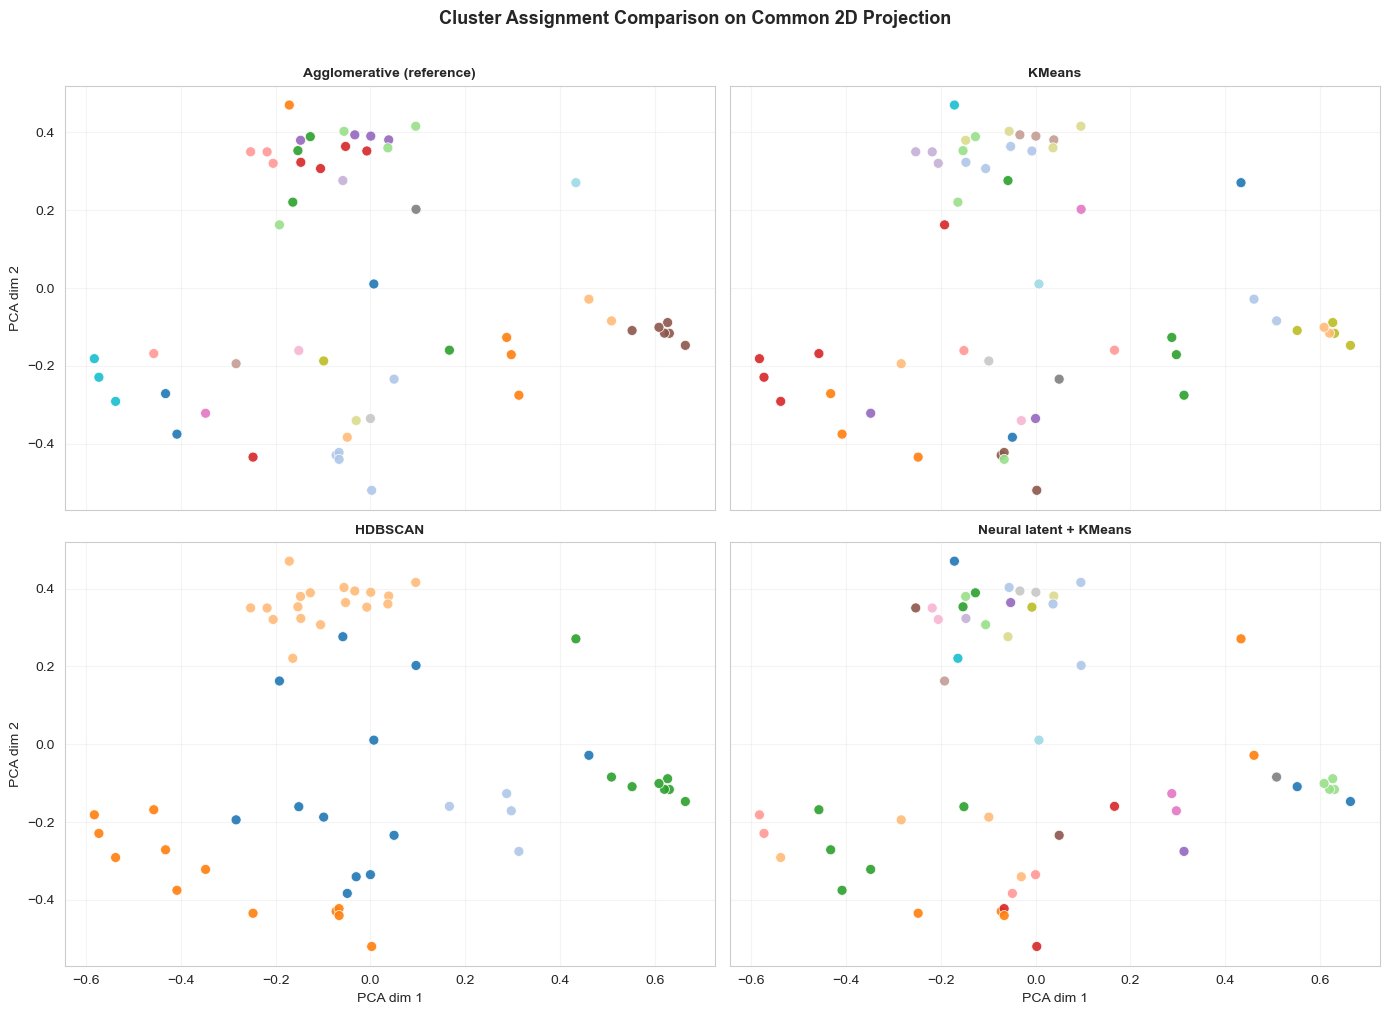

Saved benchmark table: results/test1/proposal_compression/02d_cluster_method_benchmark.csv


In [ ]:
# Extra visualizations for Test 1 with publication-ready exports.
if "test1_results" not in globals() or not isinstance(test1_results, pd.DataFrame):
    test1_results = pd.read_csv(path_test1_results)

viz_df = test1_results.copy()
viz_df.columns = [str(column).strip() for column in viz_df.columns]

# Ensure expected analysis columns are present or safely derived.
if "is_traceable" not in viz_df.columns:
    viz_df["is_traceable"] = pd.to_numeric(viz_df.get("lit_matches", 0), errors="coerce").fillna(0).gt(0)
else:
    viz_df["is_traceable"] = viz_df["is_traceable"].fillna(False).astype(bool)

if "is_novel" not in viz_df.columns:
    if "ontologically_novel" in viz_df.columns:
        viz_df["is_novel"] = viz_df["ontologically_novel"]
    else:
        viz_df["is_novel"] = np.where(viz_df["is_traceable"], "NO", "MAYBE")

for column in ["max_similarity", "avg_similarity", "lit_matches", "lit_best_score"]:
    if column in viz_df.columns:
        viz_df[column] = pd.to_numeric(viz_df[column], errors="coerce")

if "inside_convex_hull" in viz_df.columns:
    viz_df["inside_convex_hull"] = viz_df["inside_convex_hull"].fillna(False).astype(bool)
else:
    viz_df["inside_convex_hull"] = False

viz_df["model"] = viz_df["model"].astype(str)
model_order = viz_df["model"].value_counts().index.tolist()

# Terminology used in labels for clarity.
sim_train_label = "Model Proposal vs. Modality cosine similarity"
sim_lit_label = "Model Proposal vs. Literature cosine similarity"

# Unified 2-color style for this dashboard.
primary_blue = WHITE_SKY_CMAP(0.72)
secondary_gray = BLUE_GRAY_RAMP[3]

out_dir = Path("results/test1")
fig_dir = out_dir / "extra_visualizations"
fig_dir.mkdir(parents=True, exist_ok=True)
saved_files = []

# 2x2 dashboard (removed previous top-left and bottom-left figures for readability).
fig, axes = plt.subplots(2, 2, figsize=(12.0, 9.0))
fig.suptitle("Test 1: Ontological Innovation - Exploratory Visual Analytics (Focused)", fontsize=TITLE_SIZE, fontweight="bold")

# 1) Traceable vs non-traceable counts by model (stacked).
trace_counts = (
    viz_df.groupby(["model", "is_traceable"]).size().unstack(fill_value=0).reindex(model_order).fillna(0)
)
trace_counts.columns = [bool(column) for column in trace_counts.columns]
true_counts = trace_counts[True] if True in trace_counts.columns else pd.Series(0, index=model_order)
false_counts = trace_counts[False] if False in trace_counts.columns else pd.Series(0, index=model_order)

# Requested order: traceable at bottom, not traceable stacked on top.
axes[0, 0].bar(model_order, true_counts.values, color=primary_blue, label="Traceable")
axes[0, 0].bar(model_order, false_counts.values, bottom=true_counts.values, color=secondary_gray, label="Not traceable")
axes[0, 0].set_title("Traceable vs Non-traceable Counts", fontweight="bold", fontsize=TITLE_SIZE)
axes[0, 0].set_xlabel("Model", fontsize=LABEL_SIZE)
axes[0, 0].set_ylabel("Count", fontsize=LABEL_SIZE)
axes[0, 0].tick_params(axis="x", rotation=30, labelsize=TICK_SIZE)
axes[0, 0].tick_params(axis="y", labelsize=TICK_SIZE)
axes[0, 0].legend(loc="lower right", fontsize=LEGEND_SIZE)
axes[0, 0].grid(axis="y", alpha=0.2)

# 2) Max similarity distribution by model.
sns.boxplot(
    data=viz_df,
    x="model",
    y="max_similarity",
    order=model_order,
    showfliers=False,
    ax=axes[0, 1],
    color=primary_blue,
    boxprops={"alpha": 0.55},
)
sns.stripplot(
    data=viz_df,
    x="model",
    y="max_similarity",
    order=model_order,
    ax=axes[0, 1],
    size=3,
    jitter=0.22,
    alpha=0.5,
    color=secondary_gray,
)
axes[0, 1].set_title("Model Proposal vs. Modality Similarity by Model", fontweight="bold", fontsize=TITLE_SIZE)
axes[0, 1].set_xlabel("Model", fontsize=LABEL_SIZE)
axes[0, 1].set_ylabel(sim_train_label, fontsize=LABEL_SIZE)
axes[0, 1].tick_params(axis="x", rotation=30, labelsize=TICK_SIZE)
axes[0, 1].tick_params(axis="y", labelsize=TICK_SIZE)
axes[0, 1].grid(axis="y", alpha=0.2)

# 3) Relationship: max_similarity vs lit_best_score.
if "lit_best_score" in viz_df.columns and "max_similarity" in viz_df.columns:
    trace_palette = {False: secondary_gray, True: primary_blue}
    hull_markers = {False: "o", True: "s"}

    plot_scatter_df = viz_df.dropna(subset=["max_similarity", "lit_best_score"]).copy()
    available_trace = sorted(plot_scatter_df["is_traceable"].dropna().unique().tolist())

    if len(plot_scatter_df) == 0:
        axes[1, 0].text(
            0.5,
            0.5,
            "No rows have both max_similarity and lit_best_score.",
            ha="center",
            va="center",
            fontsize=LABEL_SIZE,
        )
    elif len(available_trace) == 1:
        # Single-class fallback: still show structure, but explicitly report class imbalance after NA filtering.
        only_trace = bool(available_trace[0])
        for hull_state in [False, True]:
            group = plot_scatter_df[plot_scatter_df["inside_convex_hull"] == hull_state]
            if len(group) == 0:
                continue
            axes[1, 0].scatter(
                group["max_similarity"],
                group["lit_best_score"],
                c=[trace_palette[only_trace]],
                marker=hull_markers[hull_state],
                alpha=0.82,
                s=62,
                edgecolors="white",
                linewidths=0.45,
                label=f"inside_hull={hull_state}",
            )

        if len(plot_scatter_df) >= 2:
            sns.regplot(
                data=plot_scatter_df,
                x="max_similarity",
                y="lit_best_score",
                scatter=False,
                ci=None,
                line_kws={"color": THRESHOLD_COLOR, "linewidth": 1.6, "linestyle": "--"},
                ax=axes[1, 0],
            )

        miss_false = int(((viz_df["is_traceable"] == False) & viz_df["lit_best_score"].isna()).sum())
        miss_true = int(((viz_df["is_traceable"] == True) & viz_df["lit_best_score"].isna()).sum())
        axes[1, 0].text(
            0.02,
            0.98,
            f"Only traceable={only_trace} has valid x/y points\nmissing lit_best_score: false={miss_false}, true={miss_true}",
            transform=axes[1, 0].transAxes,
            va="top",
            ha="left",
            fontsize=TICK_SIZE,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
        )
    else:
        for trace_state in [False, True]:
            for hull_state in [False, True]:
                group = plot_scatter_df[
                    (plot_scatter_df["is_traceable"] == trace_state)
                    & (plot_scatter_df["inside_convex_hull"] == hull_state)
                ]
                if len(group) == 0:
                    continue
                axes[1, 0].scatter(
                    group["max_similarity"],
                    group["lit_best_score"],
                    c=[trace_palette[trace_state]],
                    marker=hull_markers[hull_state],
                    alpha=0.82,
                    s=62,
                    edgecolors="white",
                    linewidths=0.45,
                    label=f"traceable={trace_state}, inside_hull={hull_state}",
                )

    axes[1, 0].set_title("Model Proposal vs. Modality and Literature Similarity", fontweight="bold", fontsize=TITLE_SIZE)
    axes[1, 0].set_xlabel(sim_train_label, fontsize=LABEL_SIZE)
    axes[1, 0].set_ylabel(sim_lit_label, fontsize=LABEL_SIZE)
    axes[1, 0].tick_params(axis="x", labelsize=TICK_SIZE)
    axes[1, 0].tick_params(axis="y", labelsize=TICK_SIZE)
    handles, labels = axes[1, 0].get_legend_handles_labels()
    if len(handles):
        axes[1, 0].legend(loc="best", fontsize=LEGEND_SIZE, frameon=True)
    axes[1, 0].grid(alpha=0.2)
else:
    axes[1, 0].text(0.5, 0.5, "Required columns not available", ha="center", va="center", fontsize=LABEL_SIZE)
    axes[1, 0].set_title("Model Proposal vs. Modality and Literature Similarity", fontweight="bold", fontsize=TITLE_SIZE)

# 4) Correlation heatmap for numeric diagnostics (NA-safe).
numeric_cols = [column for column in ["max_similarity", "avg_similarity", "lit_matches", "lit_best_score"] if column in viz_df.columns]
corr_df = viz_df[numeric_cols].copy() if numeric_cols else pd.DataFrame()
corr_df["is_traceable_num"] = viz_df["is_traceable"].astype(int)
corr_df["inside_hull_num"] = viz_df["inside_convex_hull"].astype(int)

if corr_df.shape[1] >= 2:
    corr = corr_df.corr(numeric_only=True)
    # Replace non-applicable correlations (NaN/inf from constant columns) with 0, then use absolute intensity.
    corr = corr.replace([np.inf, -np.inf], np.nan).fillna(0.0).abs()
    heatmap = sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap=WHITE_SKY_CMAP,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        ax=axes[1, 1],
        cbar_kws={"label": "|correlation|"},
    )
    axes[1, 1].set_title("Absolute Correlation Heatmap (0=white, 1=skyblue)", fontweight="bold", fontsize=TITLE_SIZE)
    axes[1, 1].tick_params(axis="x", rotation=90, labelsize=TICK_SIZE)
    axes[1, 1].tick_params(axis="y", labelsize=TICK_SIZE)
    if heatmap.collections:
        colorbar = heatmap.collections[0].colorbar
        if colorbar is not None:
            colorbar.ax.tick_params(labelsize=CBAR_TICK_SIZE)
            colorbar.set_label("|correlation|", fontsize=CBAR_LABEL_SIZE)
else:
    axes[1, 1].text(0.5, 0.5, "Not enough numeric columns", ha="center", va="center", fontsize=LABEL_SIZE)
    axes[1, 1].set_title("Absolute Correlation Heatmap (0=white, 1=skyblue)", fontweight="bold", fontsize=TITLE_SIZE)

fig.text(
    0.5,
    0.01,
    "Note: modality similarity (max_similarity/avg_similarity) compares model proposals with training modality descriptions; literature similarity (lit_best_score) compares model proposals with literature corpus entries.",
    ha="center",
    fontsize=TICK_SIZE,
    color="#444444",
)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
dashboard_path = out_dir / "extra_visualizations_dashboard.png"
plt.savefig(dashboard_path, dpi=320, bbox_inches="tight")
print(f"Saved dashboard: {dashboard_path}")
saved_files.append(dashboard_path)
plt.show()

### 6.5 Hierarchical View of Agglomerative Clusters

Visualize the same agglomerative structure as a dendrogram and a 2D scatter projection for interpretable cluster inspection.

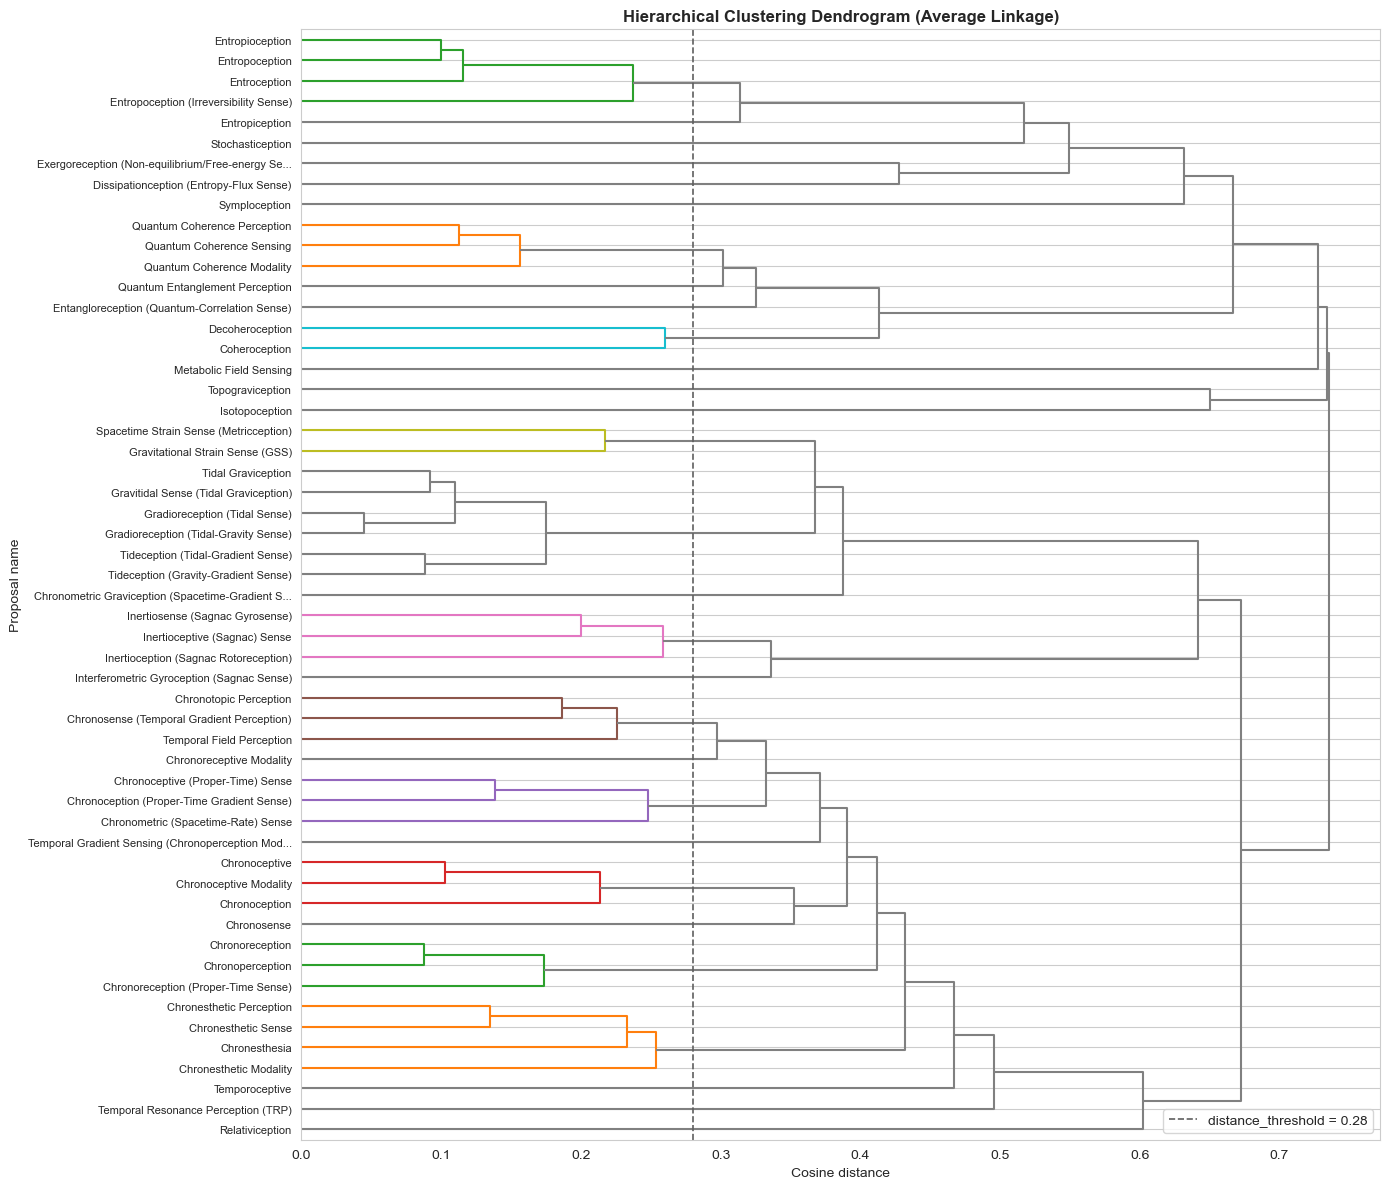

In [ ]:
if "dist_uu" not in globals() or "unique_work_df" not in globals():
    raise RuntimeError("Run the previous clustering cell first to compute dist_uu and unique_work_df.")

# Convert full distance matrix into condensed form expected by scipy linkage.
condensed_dist = squareform(dist_uu, checks=False)
Z = linkage(condensed_dist, method="average")

# Shorten overly long labels for readability in dense dendrograms.
def _short_label(text: str, max_len: int = 48) -> str:
    t = str(text).strip()
    return t if len(t) <= max_len else (t[: max_len - 1] + "...")

leaf_labels = [_short_label(x) for x in unique_work_df["proposal_name"].tolist()]

fig, ax = plt.subplots(figsize=(14, 12))
dendrogram(
    Z,
    labels=leaf_labels,
    orientation="right",
    leaf_font_size=8,
    color_threshold=distance_threshold,
    above_threshold_color="gray",
    ax=ax,
 )

# Mark the exact cut level used for AgglomerativeClustering distance_threshold.
ax.axvline(
    distance_threshold,
    color=THRESHOLD_COLOR,
    linestyle="--",
    linewidth=1.2,
    label=f"distance_threshold = {distance_threshold:.2f}",
)
ax.set_title("Hierarchical Clustering Dendrogram (Average Linkage)", fontweight="bold")
ax.set_xlabel("Cosine distance")
ax.set_ylabel("Proposal name")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.0)
plt.tight_layout()
plt.show()

#### 6.5.1 Agglomerative Cluster Scatter (PCA Projection)

Show cluster assignments in 2D with centroid labels to complement the dendrogram view.

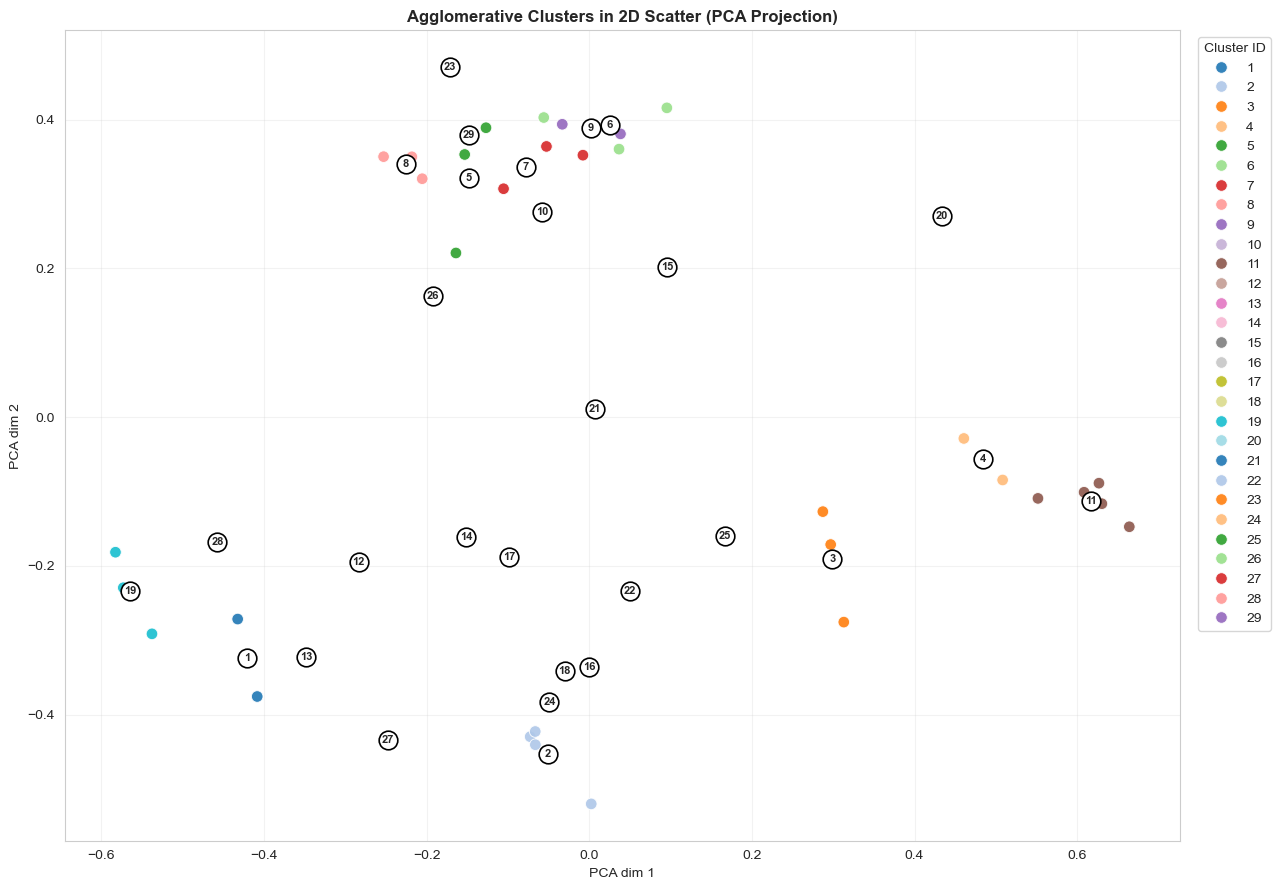

In [ ]:
if "combined_embeddings" not in globals() or "unique_work_df" not in globals():
    raise RuntimeError("Run the embedding/clustering cell first to compute combined_embeddings and unique_work_df.")

proj_2d = PCA(n_components=2, random_state=42).fit_transform(combined_embeddings)
plot_df = unique_work_df.copy()
plot_df["pca_x"] = proj_2d[:, 0]
plot_df["pca_y"] = proj_2d[:, 1]

fig, ax = plt.subplots(figsize=(12, 9))
sns.scatterplot(
    data=plot_df,
    x="pca_x",
    y="pca_y",
    hue="raw_cluster_id",
    palette="tab20",
    s=70,
    alpha=0.9,
    ax=ax,
    legend="full",
)

# Mark cluster centroids and annotate cluster IDs for quick reading.
centroids = plot_df.groupby("raw_cluster_id")[["pca_x", "pca_y"]].mean().reset_index()
ax.scatter(
    centroids["pca_x"],
    centroids["pca_y"],
    s=180,
    c="white",
    edgecolors="black",
    linewidths=1.2,
    marker="o",
    zorder=3,
)
for _, c in centroids.iterrows():
    ax.text(
        c["pca_x"],
        c["pca_y"],
        str(int(c["raw_cluster_id"])),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        zorder=4,
)

ax.set_title("Agglomerative Clusters in 2D Scatter (PCA Projection)", fontweight="bold")
ax.set_xlabel("PCA dim 1")
ax.set_ylabel("PCA dim 2")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Cluster ID")
plt.show()

### 6.6 t-SNE Projection for Local Similarity Audit

Use t-SNE to inspect local neighborhood structure among unique proposals.

#### 6.6.1 Compute t-SNE Coordinates

Project fused proposal embeddings to 2D space for label-aware visualization.

In [ ]:
perplexity = max(5, min(20, (len(unique_work_df) - 1) // 3))
tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto", perplexity=perplexity)
tsne_2d = tsne.fit_transform(combined_embeddings)
unique_work_df["tsne_x"] = tsne_2d[:, 0]
unique_work_df["tsne_y"] = tsne_2d[:, 1]

#### 6.6.2 Labeled t-SNE Visualization

Render proposal-name labels with overlap handling and connector lines for dense regions.

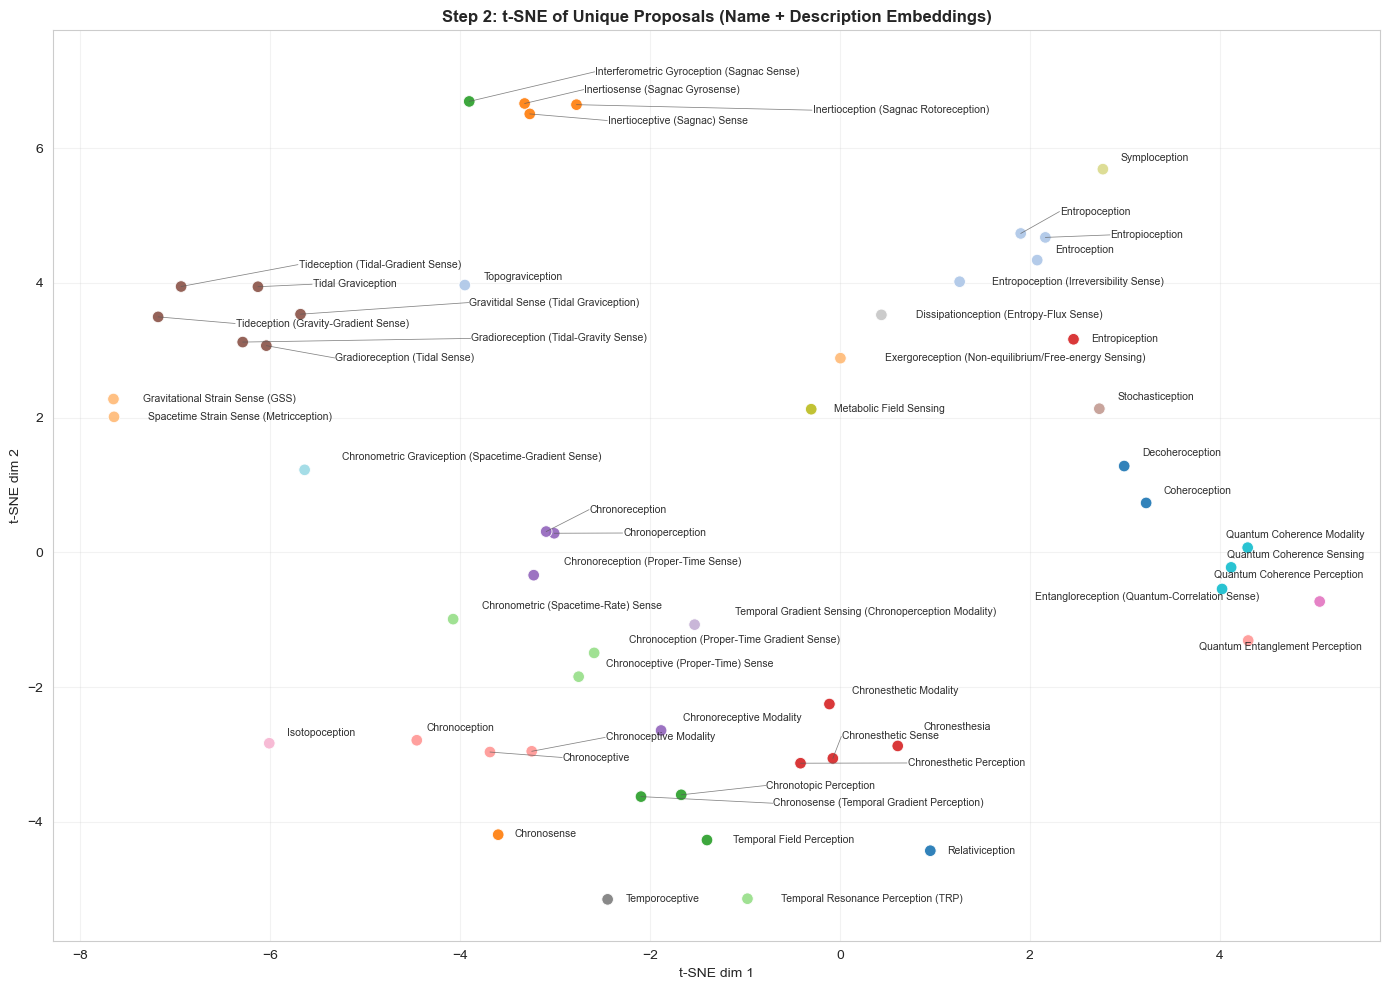

Step 2 complete
Raw clusters detected: 29
Distance threshold: 0.28
Embedding weights -> name: 0.65, description: 0.35
Label collision handling: adjustText + overlap-only bbox-left connectors
Labels with connectors: 20 / 54


,unique_names,total_occurrences
raw_cluster_id,,
8,3,34
19,3,33
26,1,23
9,3,17
2,4,9
11,6,7
27,1,6
7,4,5
1,2,5


In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))
sns.scatterplot(
    data=unique_work_df,
    x="tsne_x",
    y="tsne_y",
    hue="raw_cluster_id",
    palette="tab20",
    s=70,
    alpha=0.92,
    legend=False,
    ax=ax,
)

x_span = max(1e-8, float(unique_work_df["tsne_x"].max() - unique_work_df["tsne_x"].min()))
y_span = max(1e-8, float(unique_work_df["tsne_y"].max() - unique_work_df["tsne_y"].min()))
dx = 0.006 * x_span
dy = 0.006 * y_span

texts = []
for _, row in unique_work_df.iterrows():
    txt = ax.text(
        row["tsne_x"] + dx,
        row["tsne_y"] + dy,
        str(row["proposal_name"]),
        fontsize=7.5,
        alpha=0.96,
        ha="left",
        va="center",
    )
    texts.append(txt)

# Detect which labels overlap in the initial placement.
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
initial_bboxes = [t.get_window_extent(renderer=renderer) for t in texts]
needs_connector = [False] * len(texts)
for i in range(len(initial_bboxes)):
    for j in range(i + 1, len(initial_bboxes)):
        if initial_bboxes[i].overlaps(initial_bboxes[j]):
            needs_connector[i] = True
            needs_connector[j] = True

# Prefer automatic collision resolution if adjustText is installed (without built-in arrows).
used_adjust_text = False
try:
    from adjustText import adjust_text

    adjust_text(
        texts,
        x=unique_work_df["tsne_x"].to_numpy(),
        y=unique_work_df["tsne_y"].to_numpy(),
        ax=ax,
        expand_text=(1.08, 1.22),
        expand_points=(1.05, 1.12),
        force_text=(0.35, 0.55),
        force_points=(0.15, 0.35),
        lim=300,
    )
    used_adjust_text = True
except Exception:
    pass

# Draw connectors only for labels that had overlap pressure initially.
# Endpoint is the final rendered left edge of label bbox (pixel-precise).
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
inv = ax.transData.inverted()
for k, (txt, (_, row)) in enumerate(zip(texts, unique_work_df.iterrows())):
    if not needs_connector[k]:
        continue
    txt.set_ha("left")
    txt.set_va("center")
    bbox = txt.get_window_extent(renderer=renderer)
    x_left_px = bbox.x0 - 0.5
    y_mid_px = 0.5 * (bbox.y0 + bbox.y1)
    x1, y1 = inv.transform((x_left_px, y_mid_px))
    x0, y0 = float(row["tsne_x"]), float(row["tsne_y"])
    ax.plot([x0, x1], [y0, y1], color="0.35", lw=0.55, alpha=0.75, zorder=1)

ax.set_title("Step 2: t-SNE of Unique Proposals (Name + Description Embeddings)", fontweight="bold")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

raw_cluster_sizes = (
    unique_work_df.groupby("raw_cluster_id")
    .agg(
        unique_names=("proposal_name", "count"),
        total_occurrences=("n_occurrences", "sum"),
    )
    .sort_values(["total_occurrences", "unique_names"], ascending=[False, False])
)

print("Step 2 complete")
print(f"Raw clusters detected: {unique_work_df['raw_cluster_id'].nunique()}")
print(f"Distance threshold: {distance_threshold}")
print(f"Embedding weights -> name: {w_name:.2f}, description: {w_desc:.2f}")
print(f"Label collision handling: {'adjustText + overlap-only bbox-left connectors' if used_adjust_text else 'overlap-only bbox-left connectors'}")
print(f"Labels with connectors: {sum(needs_connector)} / {len(needs_connector)}")
display(raw_cluster_sizes.head(30))

Visualize `raw_cluster_sizes` using rank-ordered bars, a cumulative coverage curve, and size/composition scatter to inspect concentration and balance across clusters.

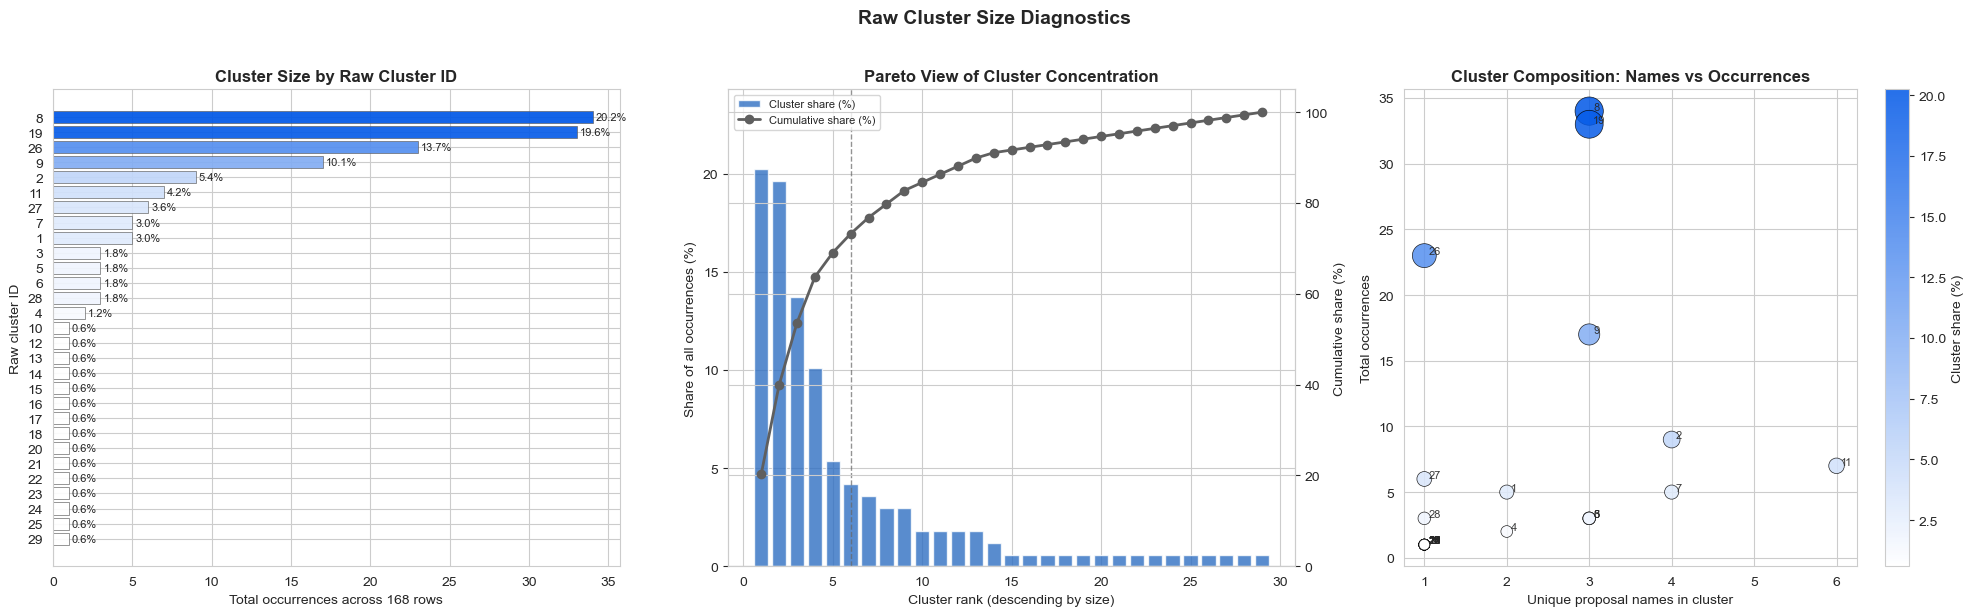

In [ ]:

 # Visual diagnostics for raw_cluster_sizes.
# If the table is not in memory (e.g., after kernel restart), rebuild it from unique_work_df.
if "raw_cluster_sizes" not in globals() or not isinstance(raw_cluster_sizes, pd.DataFrame):
    if "unique_work_df" not in globals():
        raise RuntimeError("Run the Step 2 t-SNE visualization cell first to compute raw_cluster_sizes.")
    raw_cluster_sizes = (
        unique_work_df.groupby("raw_cluster_id")
        .agg(
            unique_names=("proposal_name", "count"),
            total_occurrences=("n_occurrences", "sum"),
        )
        .sort_values(["total_occurrences", "unique_names"], ascending=[False, False])
    )

rcs = raw_cluster_sizes.reset_index().copy()
rcs = rcs.sort_values(["total_occurrences", "unique_names"], ascending=[False, False]).reset_index(drop=True)
rcs["cluster_rank"] = np.arange(1, len(rcs) + 1)
total_all = max(1, int(rcs["total_occurrences"].sum()))
rcs["share_pct"] = 100.0 * rcs["total_occurrences"] / total_all
rcs["cum_share_pct"] = rcs["share_pct"].cumsum()

# Preserve the descending-by-occurrences row order for the bar chart.
ordered_cluster_ids = rcs["raw_cluster_id"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Ranked cluster-size bar chart ordered by total_occurrences descending.
# Apply shared colormap so larger-share clusters are darker and visually consistent with notebook palette.
share_min = float(rcs["share_pct"].min())
share_max = float(rcs["share_pct"].max())
share_span = max(1e-9, share_max - share_min)
rank_colors = [
    WHITE_SKY_CMAP((float(v) - share_min) / share_span)
    for v in rcs["share_pct"].tolist()
]

axes[0].barh(
    y=np.arange(len(rcs)),
    width=rcs["total_occurrences"].to_numpy(),
    color=rank_colors,
    edgecolor=THRESHOLD_COLOR,
    linewidth=0.5,
    alpha=0.92,
)
axes[0].set_yticks(np.arange(len(rcs)))
axes[0].set_yticklabels(ordered_cluster_ids)
axes[0].invert_yaxis()

axes[0].set_title("Cluster Size by Raw Cluster ID", fontweight="bold")
axes[0].set_xlabel("Total occurrences across 168 rows")
axes[0].set_ylabel("Raw cluster ID")
for y, (_, row) in enumerate(rcs.iterrows()):
    axes[0].text(
        row["total_occurrences"] + 0.2,
        y,
        f"{row['share_pct']:.1f}%",
        va="center",
        fontsize=8,
    )

# 2) Pareto-style concentration curve.
axes[1].bar(rcs["cluster_rank"], rcs["share_pct"], color=BLUE_GRAY_RAMP[1], alpha=0.8, label="Cluster share (%)")
ax2 = axes[1].twinx()
ax2.plot(rcs["cluster_rank"], rcs["cum_share_pct"], color=THRESHOLD_COLOR, marker="o", lw=2.0, label="Cumulative share (%)")
axes[1].set_title("Pareto View of Cluster Concentration", fontweight="bold")
axes[1].set_xlabel("Cluster rank (descending by size)")
axes[1].set_ylabel("Share of all occurrences (%)")
ax2.set_ylabel("Cumulative share (%)")
axes[1].set_ylim(0, max(5, rcs["share_pct"].max() * 1.2))
ax2.set_ylim(0, 105)
axes[1].axvline(max(1, int(np.ceil(0.2 * len(rcs)))), ls="--", lw=1, color="0.4", alpha=0.7)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

# 3) Size vs composition scatter (occurrences vs unique proposal names).
sc = axes[2].scatter(
    rcs["unique_names"],
    rcs["total_occurrences"],
    s=50 + 18 * rcs["share_pct"],
    c=rcs["share_pct"],
    cmap=WHITE_SKY_CMAP,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.5,
 )
for _, row in rcs.iterrows():
    axes[2].text(
        row["unique_names"] + 0.05,
        row["total_occurrences"] + 0.1,
        str(int(row["raw_cluster_id"])),
        fontsize=8,
        alpha=0.9,
    )
axes[2].set_title("Cluster Composition: Names vs Occurrences", fontweight="bold")
axes[2].set_xlabel("Unique proposal names in cluster")
axes[2].set_ylabel("Total occurrences")
cbar = plt.colorbar(sc, ax=axes[2])
cbar.set_label("Cluster share (%)")

plt.suptitle("Raw Cluster Size Diagnostics", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#display(rcs[["raw_cluster_id", "unique_names", "total_occurrences", "share_pct", "cum_share_pct"]].head(30))


#### 6.6.3 Canonical Label Construction

Create canonical cluster labels directly from raw similarity clusters using representative (medoid-like) proposals.

In [ ]:
# Clear stale columns for idempotent re-runs.
stale_cols = ["final_cluster_key", "canonical_label", "cluster_representative", "cluster_avg_similarity"]
unique_work_df = unique_work_df.drop(columns=[c for c in stale_cols if c in unique_work_df.columns], errors="ignore")

# Keep one canonical cluster per raw similarity cluster.
unique_work_df["final_cluster_key"] = "cluster_" + unique_work_df["raw_cluster_id"].astype(str)

cluster_label_rows = []
for cid, g in unique_work_df.groupby("raw_cluster_id", sort=True):
    idx = g.index.to_numpy()
    sim_block = sim_uu[np.ix_(idx, idx)]

    # Representative (medoid-like): point with highest mean similarity inside its cluster.
    mean_sim = sim_block.mean(axis=1)
    rep_local = int(np.argmax(mean_sim))
    rep_idx = idx[rep_local]
    rep_name = str(unique_work_df.loc[rep_idx, "proposal_name"]).strip()

    canonical_label = f"C{int(cid):02d}: {rep_name}"
    cluster_label_rows.append(
        {
            "raw_cluster_id": int(cid),
            "canonical_label": canonical_label,
            "cluster_representative": rep_name,
            "cluster_avg_similarity": float(np.mean(sim_block)),
        }
    )

cluster_label_df = pd.DataFrame(cluster_label_rows)
unique_work_df = unique_work_df.merge(cluster_label_df, on="raw_cluster_id", how="left")

canonical_summary = (
    unique_work_df.groupby(["raw_cluster_id", "canonical_label", "cluster_representative"], as_index=False)
    .agg(
        unique_names=("proposal_name", "count"),
        total_occurrences=("n_occurrences", "sum"),
        cluster_avg_similarity=("cluster_avg_similarity", "first"),
        examples=("proposal_name", lambda s: "; ".join(sorted(s.tolist())[:5])),
    )
    .sort_values(["total_occurrences", "unique_names", "raw_cluster_id"], ascending=[False, False, True])
)

print("Step 3 complete")
print("Canonical labels are now data-driven and 1:1 with similarity clusters.")
print(f"Final canonical clusters: {unique_work_df['canonical_label'].nunique()}")
display(canonical_summary.head(40))

# Optional audit: inspect cluster assignments alphabetically by proposal name.
audit_view = unique_work_df[[
    "proposal_name", "raw_cluster_id", "canonical_label", "cluster_representative",
    "n_occurrences", "n_models"
]].sort_values(["raw_cluster_id", "proposal_name"]).reset_index(drop=True)
display(audit_view.head(80))

Step 3 complete
Canonical labels are now data-driven and 1:1 with similarity clusters.
Final canonical clusters: 29


,raw_cluster_id,canonical_label,cluster_representative,unique_names,total_occurrences,cluster_avg_similarity,examples
7,8,C08: Chronoceptive,Chronoceptive,3,34,0.882269,Chronoception; Chronoceptive; Chronoceptive Mo...
18,19,C19: Quantum Coherence Perception,Quantum Coherence Perception,3,33,0.905357,Quantum Coherence Modality; Quantum Coherence ...
25,26,C26: Temporal Resonance Perception (TRP),Temporal Resonance Perception (TRP),1,23,1.000000,Temporal Resonance Perception (TRP)
8,9,C09: Chronoperception,Chronoperception,3,17,0.903328,Chronoperception; Chronoreception; Chronorecep...
1,2,C02: Entropioception,Entropioception,4,9,0.869652,Entroception; Entropioception; Entropoception;...
10,11,C11: Gradioreception (Tidal-Gravity Sense),Gradioreception (Tidal-Gravity Sense),6,7,0.885278,Gradioreception (Tidal Sense); Gradioreception...
26,27,C27: Entropiception,Entropiception,1,6,1.000000,Entropiception
6,7,C07: Chronesthetic Sense,Chronesthetic Sense,4,5,0.829689,Chronesthesia; Chronesthetic Modality; Chrones...
0,1,C01: Coheroception,Coheroception,2,5,0.870071,Coheroception; Decoheroception
2,3,C03: Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,3,3,0.840530,Inertioception (Sagnac Rotoreception); Inertio...


,proposal_name,raw_cluster_id,canonical_label,cluster_representative,n_occurrences,n_models
0,Coheroception,1,C01: Coheroception,Coheroception,3,1
1,Decoheroception,1,C01: Coheroception,Coheroception,2,1
2,Entroception,2,C02: Entropioception,Entropioception,2,1
3,Entropioception,2,C02: Entropioception,Entropioception,1,1
4,Entropoception,2,C02: Entropioception,Entropioception,5,1
5,Entropoception (Irreversibility Sense),2,C02: Entropioception,Entropioception,1,1
6,Inertioception (Sagnac Rotoreception),3,C03: Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,1,1
7,Inertioceptive (Sagnac) Sense,3,C03: Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,1,1
8,Inertiosense (Sagnac Gyrosense),3,C03: Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,1,1
9,Gravitational Strain Sense (GSS),4,C04: Spacetime Strain Sense (Metricception),Spacetime Strain Sense (Metricception),1,1


#### 6.6.4 Nearest-Neighbor Audit Table

For each unique proposal, list top-3 nearest neighbors and whether they remain in the same cluster.

In [ ]:
# Step 3b. Audit table: top-3 nearest neighbors per unique proposal (cosine similarity).
if "sim_uu" not in globals() or "unique_work_df" not in globals():
    raise RuntimeError("Run Step 2 and Step 3 first: 'sim_uu' and 'unique_work_df' are required.")

n_neighbors = 3
names = unique_work_df["proposal_name"].astype(str).tolist()
cluster_ids = unique_work_df["raw_cluster_id"].tolist()

rows = []
for i, name in enumerate(names):
    sims = sim_uu[i].copy()
    sims[i] = -1.0  # Exclude self-match.
    nn_idx = np.argsort(sims)[-n_neighbors:][::-1]

    row = {
        "proposal_name": name,
        "raw_cluster_id": int(cluster_ids[i]),
        "canonical_label": unique_work_df.iloc[i]["canonical_label"],
    }

    for rank, j in enumerate(nn_idx, start=1):
        row[f"nn{rank}_name"] = names[j]
        row[f"nn{rank}_similarity"] = float(sims[j])
        row[f"nn{rank}_same_cluster"] = bool(cluster_ids[i] == cluster_ids[j])

    rows.append(row)

top3_neighbors_df = pd.DataFrame(rows)

# Human-readable sorting: weakest local support first (lowest top-1 similarity).
top3_neighbors_df = top3_neighbors_df.sort_values(
    ["raw_cluster_id", "nn1_similarity", "proposal_name"],
    ascending=[True, True, True]
).reset_index(drop=True)

display(top3_neighbors_df.head(120))

# Save for appendix and manual labeling audit.
audit_dir = Path("results/test1/proposal_compression")
audit_dir.mkdir(parents=True, exist_ok=True)
audit_path = audit_dir / "03b_top3_nearest_neighbors.csv"
top3_neighbors_df.to_csv(audit_path, index=False)
print(f"Saved nearest-neighbor audit table: {audit_path}")

# Optional quick diagnostics.
same_cluster_rate = top3_neighbors_df[["nn1_same_cluster", "nn2_same_cluster", "nn3_same_cluster"]].mean()
print("Top-k same-cluster rate:")
print((same_cluster_rate * 100).round(1).astype(str) + "%")

,proposal_name,raw_cluster_id,canonical_label,nn1_name,nn1_similarity,nn1_same_cluster,nn2_name,nn2_similarity,nn2_same_cluster,nn3_name,nn3_similarity,nn3_same_cluster
0,Coheroception,1,C01: Coheroception,Decoheroception,0.740141,True,Quantum Coherence Sensing,0.685682,False,Quantum Coherence Perception,0.674249,False
1,Decoheroception,1,C01: Coheroception,Coheroception,0.740141,True,Entropiception,0.658058,False,Quantum Coherence Perception,0.638697,False
2,Entropoception (Irreversibility Sense),2,C02: Entropioception,Entroception,0.771894,True,Entropioception,0.763569,True,Entropoception,0.751970,True
3,Entroception,2,C02: Entropioception,Entropioception,0.890445,True,Entropoception,0.878882,True,Entropoception (Irreversibility Sense),0.771894,True
4,Entropioception,2,C02: Entropioception,Entropoception,0.900456,True,Entroception,0.890445,True,Entropoception (Irreversibility Sense),0.763569,True
5,Entropoception,2,C02: Entropioception,Entropioception,0.900456,True,Entroception,0.878882,True,Entropoception (Irreversibility Sense),0.751970,True
6,Inertioception (Sagnac Rotoreception),3,C03: Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,0.759332,True,Inertiosense (Sagnac Gyrosense),0.723040,True,Interferometric Gyroception (Sagnac Sense),0.588657,False
7,Inertioceptive (Sagnac) Sense,3,C03: Inertioceptive (Sagnac) Sense,Inertiosense (Sagnac Gyrosense),0.800011,True,Inertioception (Sagnac Rotoreception),0.759332,True,Interferometric Gyroception (Sagnac Sense),0.703844,False
8,Inertiosense (Sagnac Gyrosense),3,C03: Inertioceptive (Sagnac) Sense,Inertioceptive (Sagnac) Sense,0.800011,True,Inertioception (Sagnac Rotoreception),0.723040,True,Interferometric Gyroception (Sagnac Sense),0.700282,False
9,Gravitational Strain Sense (GSS),4,C04: Spacetime Strain Sense (Metricception),Spacetime Strain Sense (Metricception),0.782812,True,Tideception (Gravity-Gradient Sense),0.703376,False,Gravitidal Sense (Tidal Graviception),0.691233,False


Saved nearest-neighbor audit table: results/test1/proposal_compression/03b_top3_nearest_neighbors.csv
Top-k same-cluster rate:
nn1_same_cluster    66.7%
nn2_same_cluster    53.7%
nn3_same_cluster    25.9%
dtype: object


#### 6.6.5 Boundary-Case Flagging

Flag potentially ambiguous assignments using low top-1 similarity and weak same-cluster agreement among top neighbors.

In [ ]:
# Step 3c. Boundary-case flags: likely ambiguous or weakly grouped proposals.
if "top3_neighbors_df" not in globals():
    raise RuntimeError("Run Step 3b first: 'top3_neighbors_df' is required.")

# Tunable thresholds for audit strictness.
low_similarity_threshold = 0.55
neighbor_agreement_min = 2  # require at least 2 of top-3 neighbors in same cluster for strong support

tmp = top3_neighbors_df.copy()
tmp["same_cluster_count_top3"] = (
    tmp[["nn1_same_cluster", "nn2_same_cluster", "nn3_same_cluster"]]
    .astype(int)
    .sum(axis=1)
)

flagged_boundary_df = tmp[
    (tmp["nn1_similarity"] < low_similarity_threshold)
    | (~tmp["nn1_same_cluster"])
    | (tmp["same_cluster_count_top3"] < neighbor_agreement_min)
][[
    "proposal_name",
    "raw_cluster_id",
    "canonical_label",
    "nn1_name", "nn1_similarity", "nn1_same_cluster",
    "nn2_name", "nn2_similarity", "nn2_same_cluster",
    "nn3_name", "nn3_similarity", "nn3_same_cluster",
    "same_cluster_count_top3",
]].sort_values([
    "nn1_same_cluster", "same_cluster_count_top3", "nn1_similarity", "proposal_name"
], ascending=[True, True, True, True]).reset_index(drop=True)

print("Step 3c complete")
print(f"Flagged boundary cases: {len(flagged_boundary_df)} / {len(top3_neighbors_df)}")
print(f"low_similarity_threshold = {low_similarity_threshold}")
print(f"neighbor_agreement_min = {neighbor_agreement_min}")
display(flagged_boundary_df)

flag_path = Path("results/test1/proposal_compression/03c_flagged_boundary_cases.csv")
flagged_boundary_df.to_csv(flag_path, index=False)
print(f"Saved boundary-case flags: {flag_path}")

Step 3c complete
Flagged boundary cases: 23 / 54
low_similarity_threshold = 0.55
neighbor_agreement_min = 2


,proposal_name,raw_cluster_id,canonical_label,nn1_name,nn1_similarity,nn1_same_cluster,nn2_name,nn2_similarity,nn2_same_cluster,nn3_name,nn3_similarity,nn3_same_cluster,same_cluster_count_top3
0,Topograviception,22,C22: Topograviception,Gravitidal Sense (Tidal Graviception),0.412194,False,Coheroception,0.373953,False,Inertioceptive (Sagnac) Sense,0.373321,False,0
1,Relativiception,21,C21: Relativiception,Chronesthetic Sense,0.473506,False,Temporoceptive,0.465787,False,Chronesthetic Perception,0.444899,False,0
2,Metabolic Field Sensing,17,C17: Metabolic Field Sensing,Exergoreception (Non-equilibrium/Free-energy S...,0.495590,False,Temporal Gradient Sensing (Chronoperception Mo...,0.415112,False,Dissipationception (Entropy-Flux Sense),0.379280,False,0
3,Isotopoception,14,C14: Isotopoception,Decoheroception,0.516901,False,Chronoception,0.514576,False,Coheroception,0.438231,False,0
4,Symploception,18,C18: Symploception,Entropioception,0.527417,False,Entropoception,0.477782,False,Entroception,0.456148,False,0
5,Exergoreception (Non-equilibrium/Free-energy S...,24,C24: Exergoreception (Non-equilibrium/Free-ene...,Dissipationception (Entropy-Flux Sense),0.572310,False,Entropoception (Irreversibility Sense),0.537641,False,Metabolic Field Sensing,0.495590,False,0
6,Dissipationception (Entropy-Flux Sense),16,C16: Dissipationception (Entropy-Flux Sense),Entropoception (Irreversibility Sense),0.620293,False,Exergoreception (Non-equilibrium/Free-energy S...,0.572310,False,Entropoception,0.522050,False,0
7,Stochastiception,12,C12: Stochastiception,Decoheroception,0.633672,False,Entropiception,0.628081,False,Coheroception,0.509411,False,0
8,Temporoceptive,15,C15: Temporoceptive,Chronoceptive (Proper-Time) Sense,0.634020,False,Chronoreceptive Modality,0.627268,False,Chronosense (Temporal Gradient Perception),0.618336,False,0
9,Temporal Resonance Perception (TRP),26,C26: Temporal Resonance Perception (TRP),Temporal Field Perception,0.662421,False,Chronosense (Temporal Gradient Perception),0.649971,False,Chronotopic Perception,0.620556,False,0


Saved boundary-case flags: results/test1/proposal_compression/03c_flagged_boundary_cases.csv


#### 6.6.6 Apply Canonical Mapping and Export Artifacts

Map canonical labels back to all proposal rows and export summary tables and heatmap outputs.

Saved model-cluster heatmap: results/test1/proposal_compression/06_canonical_by_model_heatmap.png


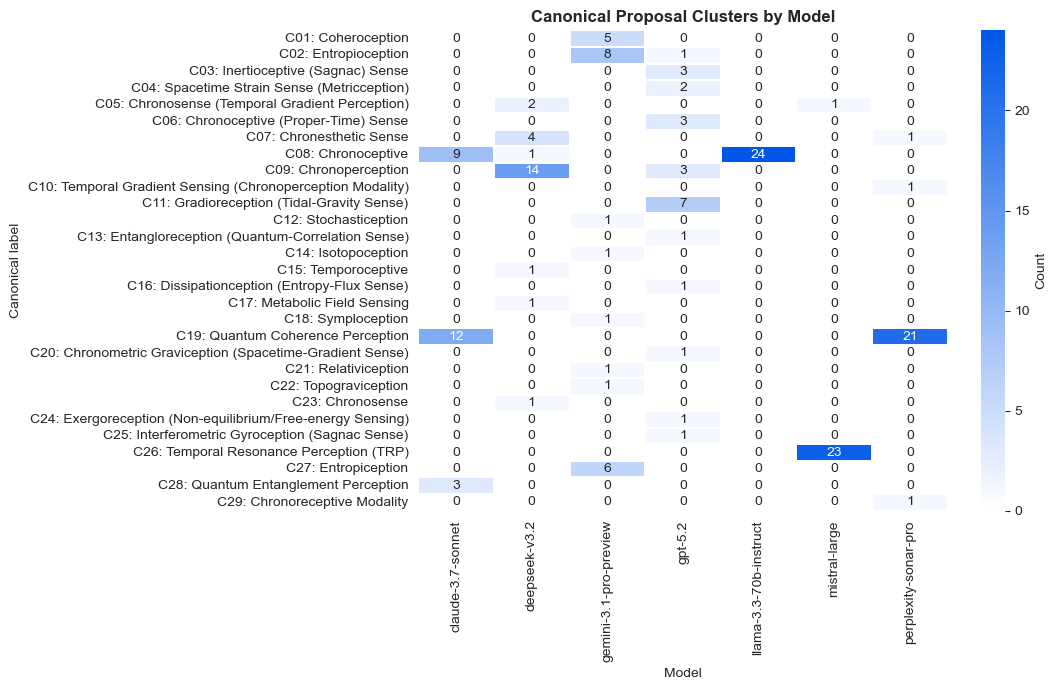

In [ ]:
# Step 4. Apply canonical labels to all 168 rows and export compression artifacts.
compression_dir = Path("results/test1/proposal_compression")
compression_dir.mkdir(parents=True, exist_ok=True)

# Map unique proposal_name -> canonical label.
name_to_canonical = unique_work_df[["proposal_name", "canonical_label", "final_cluster_key", "raw_cluster_id"]].copy()

compressed_all = ai_df.merge(
    name_to_canonical,
    on="proposal_name",
    how="left",
    validate="many_to_one",
)

if compressed_all["canonical_label"].isna().any():
    missing = compressed_all.loc[compressed_all["canonical_label"].isna(), "proposal_name"].unique().tolist()
    raise ValueError(f"Unmapped proposal names found: {missing[:10]}")

final_summary = (
    compressed_all.groupby("canonical_label")
    .agg(
        total_rows=("proposal_id", "count"),
        unique_names=("proposal_name", "nunique"),
        models=("model", "nunique"),
    )
    .sort_values(["total_rows", "unique_names"], ascending=[False, False])
    .reset_index()
)

# Optional model-by-cluster table for paper appendix.
model_cluster_table = pd.crosstab(compressed_all["canonical_label"], compressed_all["model"])

# Save outputs.
unique_exact_df.to_csv(compression_dir / "01_unique_exact_names.csv", index=False)
unique_work_df.sort_values(["canonical_label", "proposal_name"]).to_csv(
    compression_dir / "02_unique_names_with_clusters.csv", index=False
)
compressed_all.to_csv(compression_dir / "03_all_168_with_canonical_labels.csv", index=False)
final_summary.to_csv(compression_dir / "04_canonical_cluster_summary.csv", index=False)
model_cluster_table.to_csv(compression_dir / "05_canonical_by_model_table.csv")

# Compact table-like heatmap for canonical x model counts.
plt.figure(figsize=(11, 7))
sns.heatmap(model_cluster_table, cmap=WHITE_SKY_CMAP, annot=True, fmt=".0f", linewidths=0.3, cbar_kws={"label": "Count"})
plt.title("Canonical Proposal Clusters by Model", fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Canonical label")
plt.tight_layout()
plt.savefig(compression_dir / "06_canonical_by_model_heatmap.png", dpi=320, bbox_inches="tight")
print(f"Saved model-cluster heatmap: {compression_dir / '06_canonical_by_model_heatmap.png'}")
plt.show()

In [ ]:
print("Step 4 complete")
print(f"Rows preserved after compression mapping: {len(compressed_all)} (expected 168)")
print(f"Canonical clusters: {final_summary.shape[0]}")
print(f"Saved artifacts to: {compression_dir}")
display(final_summary)
display(model_cluster_table)

Step 4 complete
Rows preserved after compression mapping: 168 (expected 168)
Canonical clusters: 29
Saved artifacts to: results/test1/proposal_compression


,canonical_label,total_rows,unique_names,models
0,C08: Chronoceptive,34,3,3
1,C19: Quantum Coherence Perception,33,3,2
2,C26: Temporal Resonance Perception (TRP),23,1,1
3,C09: Chronoperception,17,3,2
4,C02: Entropioception,9,4,2
5,C11: Gradioreception (Tidal-Gravity Sense),7,6,1
6,C27: Entropiception,6,1,1
7,C07: Chronesthetic Sense,5,4,2
8,C01: Coheroception,5,2,1
9,C03: Inertioceptive (Sagnac) Sense,3,3,1


model,claude-3.7-sonnet,deepseek-v3.2,gemini-3.1-pro-preview,gpt-5.2,llama-3.3-70b-instruct,mistral-large,perplexity-sonar-pro
canonical_label,,,,,,,
C01: Coheroception,0,0,5,0,0,0,0
C02: Entropioception,0,0,8,1,0,0,0
C03: Inertioceptive (Sagnac) Sense,0,0,0,3,0,0,0
C04: Spacetime Strain Sense (Metricception),0,0,0,2,0,0,0
C05: Chronosense (Temporal Gradient Perception),0,2,0,0,0,1,0
C06: Chronoceptive (Proper-Time) Sense,0,0,0,3,0,0,0
C07: Chronesthetic Sense,0,4,0,0,0,0,1
C08: Chronoceptive,9,1,0,0,24,0,0
C09: Chronoperception,0,14,0,3,0,0,0


## 7. Detailed Examples Analysis

In [ ]:
test1_results = pd.read_csv(path_test1_results)

# If classification is absent (e.g., section 6 cell was skipped), derive a lightweight fallback.
if "classification" not in test1_results.columns:
    if "is_novel" in test1_results.columns:
        test1_results["classification"] = np.where(
            test1_results["is_novel"].astype(str).str.upper().eq("NO"),
            "Literature Traceable",
            "Recombination",
        )
    elif "ontologically_novel" in test1_results.columns:
        # Legacy fallback
        test1_results["classification"] = np.where(
            test1_results["ontologically_novel"].astype(str).str.upper().eq("NO"),
            "Literature Traceable",
            "Recombination",
        )
    else:
        test1_results["classification"] = "Unclassified"

name_col = "proposal_name" if "proposal_name" in test1_results.columns else "modality_name"
desc_col = "description" if "description" in test1_results.columns else "lit_best_text"
nov_col = "novelty_score" if "novelty_score" in test1_results.columns else "novelty_score_proxy"

if nov_col not in test1_results.columns:
    sim = pd.to_numeric(test1_results.get("max_similarity", np.nan), errors="coerce")
    test1_results[nov_col] = (1.0 - sim).clip(lower=0.0, upper=1.0)

print("\n=== REPRESENTATIVE EXAMPLES ===")

for classification in test1_results["classification"].astype(str).unique():
    print(f"\n{classification}:")
    examples = test1_results[test1_results["classification"] == classification].head(2)
    for _, ex in examples.iterrows():
        novelty_val = float(pd.to_numeric(ex.get(nov_col, np.nan), errors="coerce"))
        sim_val = float(pd.to_numeric(ex.get("max_similarity", np.nan), errors="coerce"))
        print(f"\n  Model: {ex.get('model', 'N/A')}")
        print(f"  Proposal: {ex.get(name_col, 'N/A')}")
        print(f"  Description: {str(ex.get(desc_col, ''))[:200]}...")
        print(f"  Novelty Score: {novelty_val:.2f}")
        print(f"  Similarity to Literature: {sim_val:.3f}")
        print(f"  Inside Hull: {bool(ex.get('inside_convex_hull', False))}")

# Export updated detailed results (including classification, etc.)
test1_results.to_csv("results/test1/detailed_results.csv", index=False)
print("\n=== TEST 1 ANALYSIS COMPLETE ===")
print("Results saved to results/test1/")


=== REPRESENTATIVE EXAMPLES ===

Literature Traceable:

  Model: deepseek-v3.2
  Proposal: Chronesthesia
  Description: This paper introduces the concept of Human State Field as a proposed framework for understanding how individuals perceive and experience time. We explore how various internal and external inputs affec...
  Novelty Score: 0.55
  Similarity to Literature: 0.449
  Inside Hull: True

  Model: mistral-large
  Proposal: Temporal Resonance Perception (TRP)
  Description: This paper introduces the concept of Human State Field as a proposed framework for understanding how individuals perceive and experience time. We explore how various internal and external inputs affec...
  Novelty Score: 0.70
  Similarity to Literature: 0.298
  Inside Hull: True

=== TEST 1 ANALYSIS COMPLETE ===
Results saved to results/test1/
